In [257]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,create_df_by_type_nostart,edge_outliers
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,calculate_speed
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [258]:
from matplotlib.gridspec import GridSpec

In [2]:
def get_head_angle(df):
        for ind, row in df.iterrows():
            leftear_x = row['ts_leftear_x_cm']
            leftear_y = row['ts_leftear_y_cm']
            rightear_x = row['ts_rightear_x_cm']
            rightear_y = row['ts_rightear_y_cm']
            nose_x = row['ts_nose_x_cm']
            nose_y = row['ts_nose_y_cm']
            angs = []
            if row.odd == 'left':
                for step in range(len(leftear_x)):
                    ang = np.arctan2(np.mean([leftear_y[step],rightear_y[step]])-nose_y[step],(np.mean([leftear_x[step],rightear_x[step]])-nose_x[step])*-1)
                    angs.append(ang)
            else:
                for step in range(len(leftear_x)):
                    ang = np.arctan2(np.mean([leftear_y[step],rightear_y[step]])-nose_y[step],(np.mean([leftear_x[step],rightear_x[step]])-nose_x[step]))
                    angs.append(ang)

            df.at[ind, 'head_angle'] = gaussian_filter(np.array(np.degrees(angs)),3,mode = 'reflect').astype(object)
def angular_velocity_head(df):
    for ind,row in df.iterrows():
        #filtered_head_angle = gaussian_filter(row.head_angle.astype(float),2)
        df.at[ind,'head_angle_velocity'] = calculate_angular_velocity(row.head_angle.astype(float),60).astype(object)
def angular_velocity_head_corner(df):
    for ind,row in df.iterrows():
        #filtered_head_angle = gaussian_filter(row.head_angle.astype(float),2)
        trace = gaussian_filter(np.array((row.ts_zero_out_angle_to_corner.astype(float))),3,mode = 'reflect').astype(object)
        
        df.at[ind,'head_corner_angle_velocity'] = calculate_angular_velocity(trace.astype(float),60).astype(object)
def distance_at_head_turn(df):
    for ind,row in df.iterrows():
        thresh = row.head_corner_angle_velocity[:int(row.obstacle_ind)].argmin()
        df.at[ind,'distance_at_head_turn'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][thresh]
        

def intial_lateral_error(df):
    for ind,row in df.iterrows():
        if type(row.lateral_error)==float:
            df.at[ind,'intial_lateral_error'] = np.nan
        else:
            df.at[ind,'intial_lateral_error'] = row.lateral_error[0]
         
def avg_lateral_error(df):
    for ind,row in df.iterrows():
        if type(row.lateral_error)==float:
            df.at[ind,'avg_lateral_error'] = np.nan
        else:
            df.at[ind,'avg_lateral_error'] = np.nanmean(row.lateral_error[:int(row.obstacle_ind)])
        
        
def calculate_angular_velocity(angles, frame_rate):
    # Convert angles to radians if they are given in degrees
    angles = np.radians(angles)

    # Calculate angular velocity using NumPy's array operations
    angular_displacements = np.diff(angles)
    angular_velocities = angular_displacements / (1 / frame_rate)
    np.angle(angular_velocities.astype(float))
    return angular_velocities

In [3]:
light = pd.read_hdf(r'd:\obstacle_avoidance\metadata\SFN\data\light_oa.h5')
light = drop_nans_in_columns(light,'obstacle_ind')
#light = drop_nans_in_columns(light,'lateral_error')

In [4]:
get_head_angle(light)
angular_velocity_head(light)
angular_velocity_head_corner(light)
distance_at_head_turn(light)
intial_lateral_error(light)
avg_lateral_error(light)
calculate_speed(light)


In [10]:
long,short,middle = create_df_by_type(light)

In [113]:
calculate_speed(light)

In [226]:
avg_lateral_error(light)

In [227]:
intial_lateral_error(light)

In [275]:
light.to_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\light_oa.h5",'w')

<AxesSubplot: xlabel='date_index', ylabel='intial_lateral_error'>

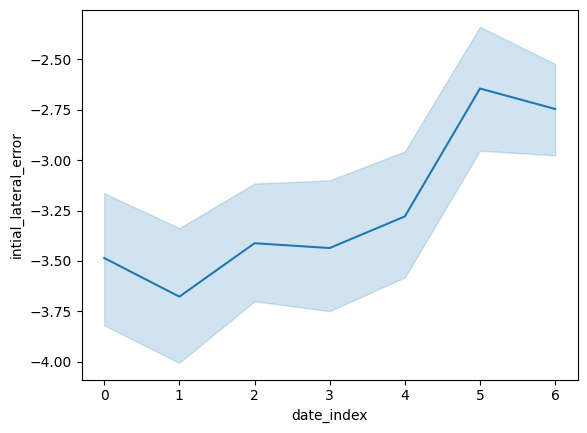

In [7]:
sns.lineplot(data = light,x = 'date_index',y = 'intial_lateral_error')

<AxesSubplot: >

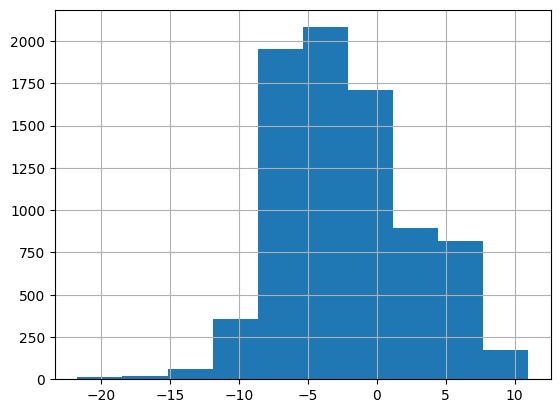

In [6]:
light.avg_lateral_error.hist()


<AxesSubplot: xlabel='date_index', ylabel='avg_lateral_error'>

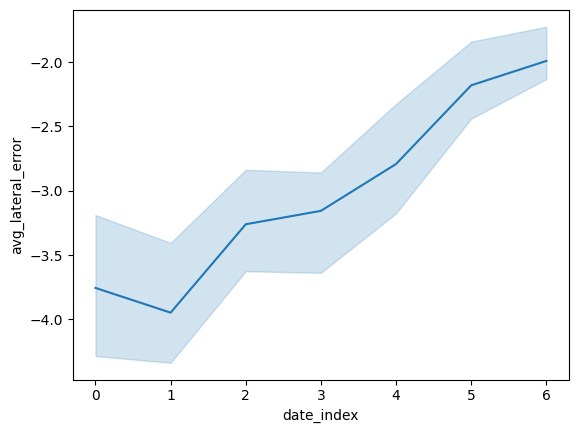

In [11]:
sns.lineplot(data = light,x = 'date_index',y = 'avg_lateral_error',estimator='median')

<AxesSubplot: xlabel='date_index', ylabel='avg_lateral_error'>

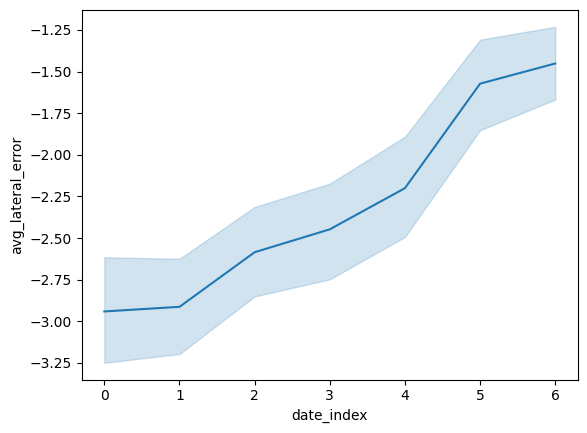

In [9]:
sns.lineplot(data = light,x = 'date_index',y = 'avg_lateral_error')

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

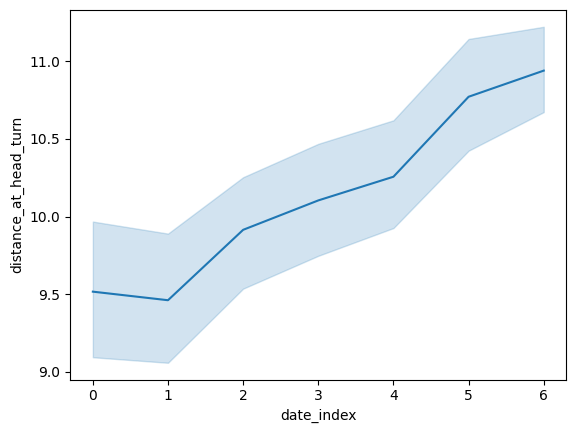

In [57]:
sns.lineplot(data = light,x = 'date_index',y = 'distance_at_head_turn')

<AxesSubplot: xlabel='date_index', ylabel='intial_lateral_error'>

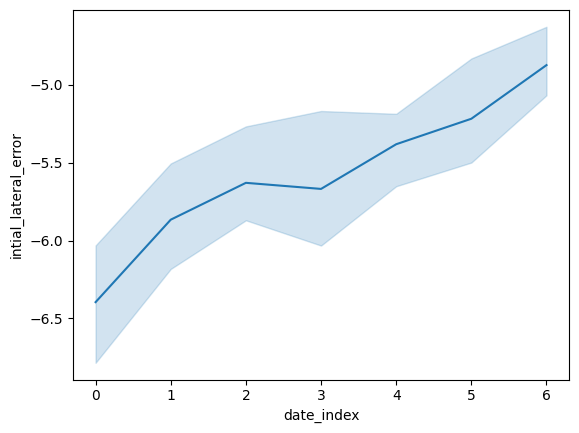

In [249]:
sns.lineplot(data = long,x = 'date_index',y = 'intial_lateral_error',estimator='median')

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

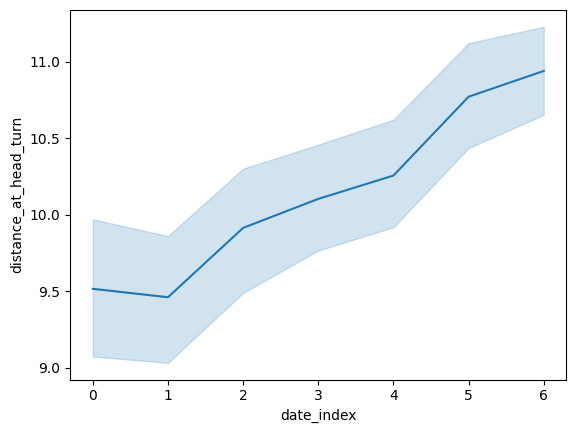

In [73]:
sns.lineplot(data = light,x = 'date_index',y = 'distance_at_head_turn')

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

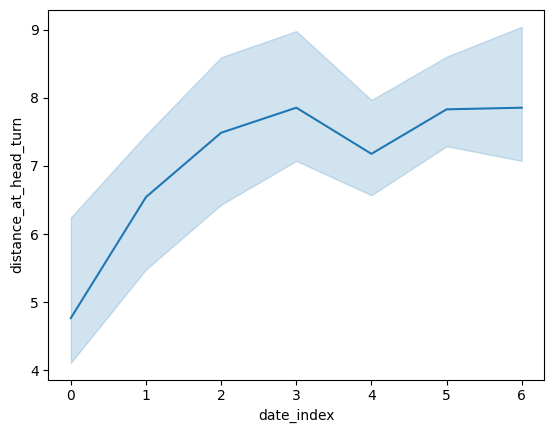

In [286]:
sns.lineplot(data = long[(long.avg_lateral_error<=-3)],x = 'date_index',y = 'distance_at_head_turn',estimator='median')

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

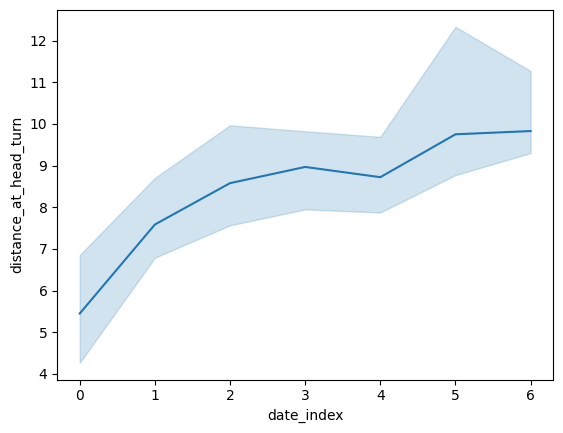

In [288]:
sns.lineplot(data = long[(long.intial_lateral_error<=-3)],x = 'date_index',y = 'distance_at_head_turn',estimator='median')

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

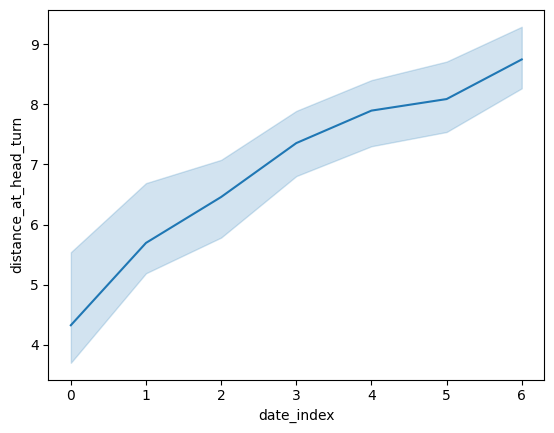

In [284]:
sns.lineplot(data = light[(light.intial_lateral_error<=-3)],x = 'date_index',y = 'distance_at_head_turn',estimator='median')

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

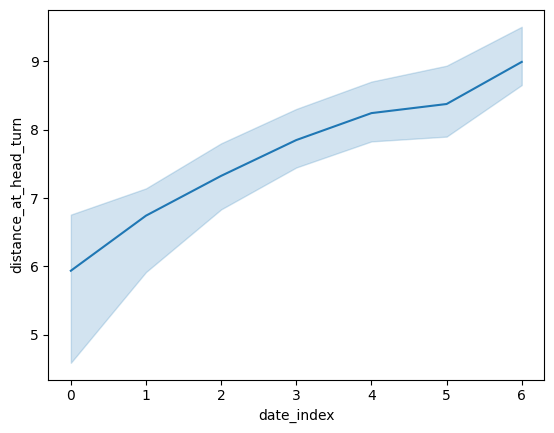

In [95]:
sns.lineplot(data = light[(light.intial_lateral_error<=0)],x = 'date_index',y = 'distance_at_head_turn',estimator='median')

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

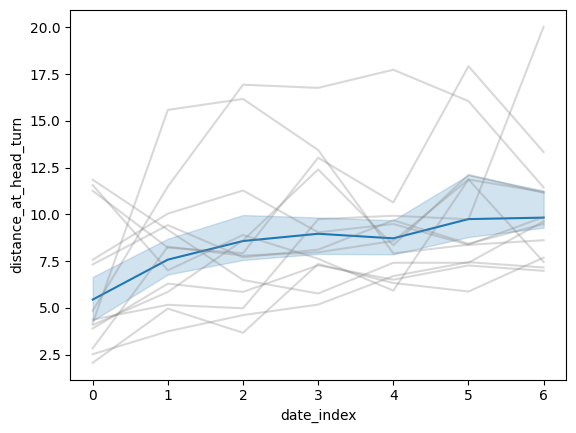

In [290]:
palette = sns.color_palette(['grey'], len(long['animal'].unique()))
sns.lineplot(data = long[(long.intial_lateral_error<=-3)],x = 'date_index',y = 'distance_at_head_turn',estimator='median')
sns.lineplot(data=long[(long.intial_lateral_error<=-3)],x='date_index',y='distance_at_head_turn',estimator='median',hue ='animal',legend=False,palette = palette,ci =None,alpha = .3)

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

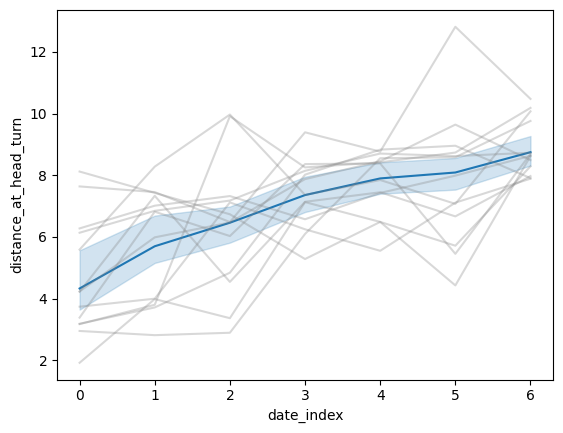

In [101]:
palette = sns.color_palette(['grey'], len(light['animal'].unique()))
sns.lineplot(data = light[(light.intial_lateral_error<=-3)],x = 'date_index',y = 'distance_at_head_turn',estimator='median')
sns.lineplot(data=light[(light.intial_lateral_error<=-3)],x='date_index',y='distance_at_head_turn',estimator='median',hue ='animal',legend=False,palette = palette,ci =None,alpha = .3)

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

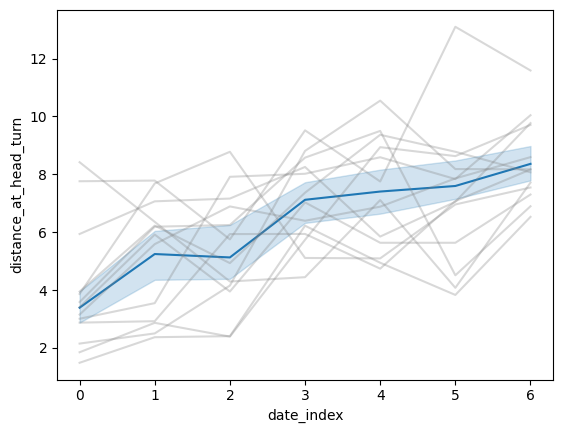

In [102]:
palette = sns.color_palette(['grey'], len(light['animal'].unique()))
sns.lineplot(data = light[(light.intial_lateral_error<=-5)],x = 'date_index',y = 'distance_at_head_turn',estimator='median')
sns.lineplot(data=light[(light.intial_lateral_error<=-5)],x='date_index',y='distance_at_head_turn',estimator='median',hue ='animal',legend=False,palette = palette,ci =None,alpha = .3)

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

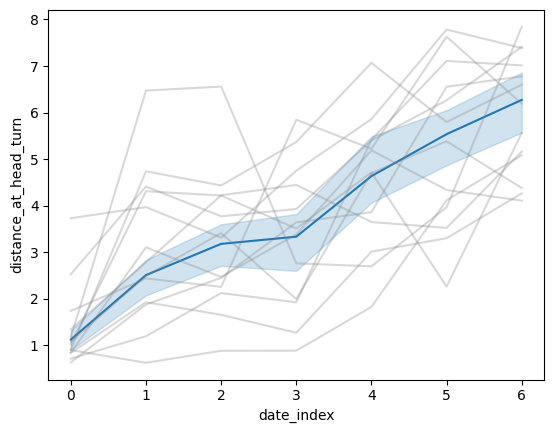

In [279]:
palette = sns.color_palette(['grey'], len(short['animal'].unique()))
sns.lineplot(data = short[short.intial_lateral_error<=-3],x = 'date_index',y = 'distance_at_head_turn',estimator='median')
sns.lineplot(data=short[(short.intial_lateral_error<=-3)],x='date_index',y='distance_at_head_turn',hue ='animal',legend=False,palette = palette,ci =None,alpha = .3,estimator='median')

<AxesSubplot: >

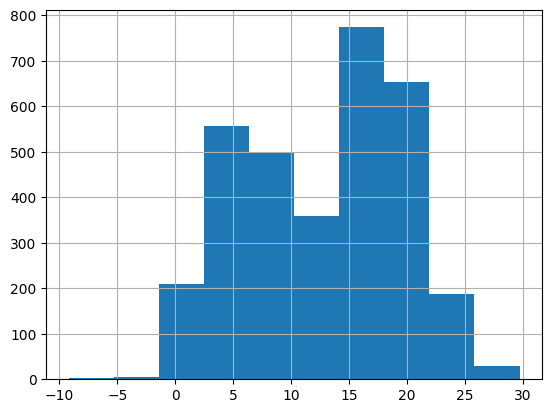

In [281]:
long.distance_at_head_turn.hist()

<AxesSubplot: >

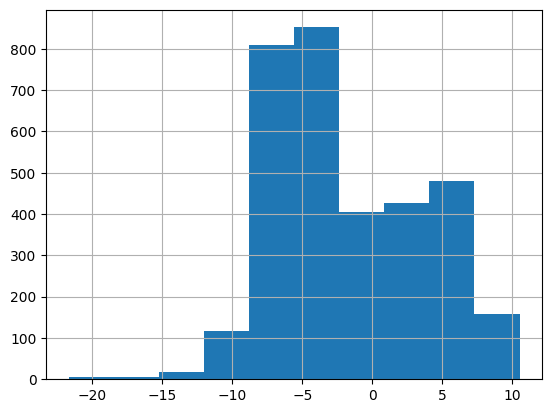

In [280]:
long.avg_lateral_error.hist()

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

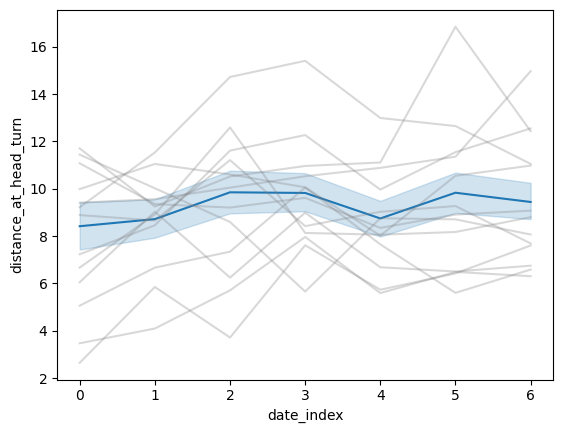

In [278]:
palette = sns.color_palette(['grey'], len(long['animal'].unique()))
sns.lineplot(data = long[long.avg_lateral_error<=-3],x = 'date_index',y = 'distance_at_head_turn',estimator='mean')
sns.lineplot(data=long[(long.avg_lateral_error<=-3)],x='date_index',y='distance_at_head_turn',hue ='animal',legend=False,palette = palette,ci =None,alpha = .3,estimator='mean')

<AxesSubplot: >

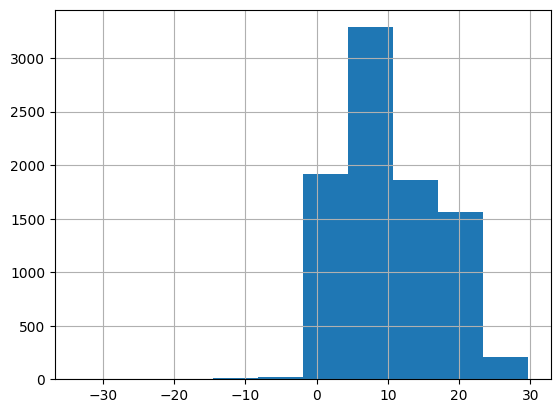

In [16]:
light.distance_at_head_turn.hist()

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

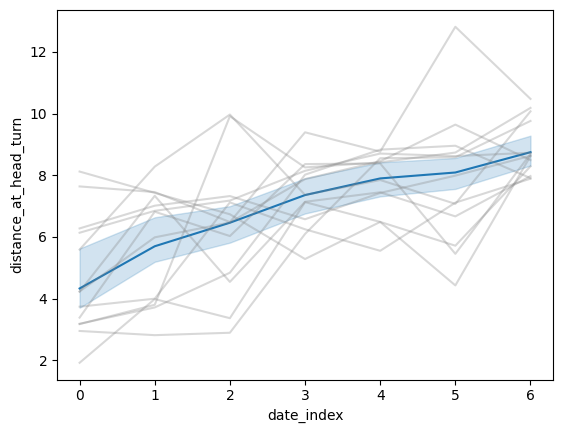

In [14]:
palette = sns.color_palette(['grey'], len(light['animal'].unique()))
sns.lineplot(data = light[light.intial_lateral_error<=-3],x = 'date_index',y = 'distance_at_head_turn',estimator='median')
sns.lineplot(data=light[(light.intial_lateral_error<=-3)],x='date_index',y='distance_at_head_turn',hue ='animal',legend=False,palette = palette,ci =None,alpha = .3,estimator='median')

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

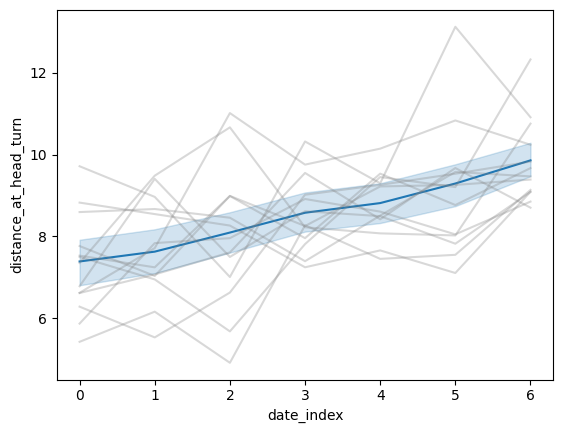

In [13]:
palette = sns.color_palette(['grey'], len(light['animal'].unique()))
sns.lineplot(data = light[light.intial_lateral_error<=-3],x = 'date_index',y = 'distance_at_head_turn',estimator='mean')
sns.lineplot(data=light[(light.intial_lateral_error<=-3)],x='date_index',y='distance_at_head_turn',hue ='animal',legend=False,palette = palette,ci =None,alpha = .3,estimator='mean')

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

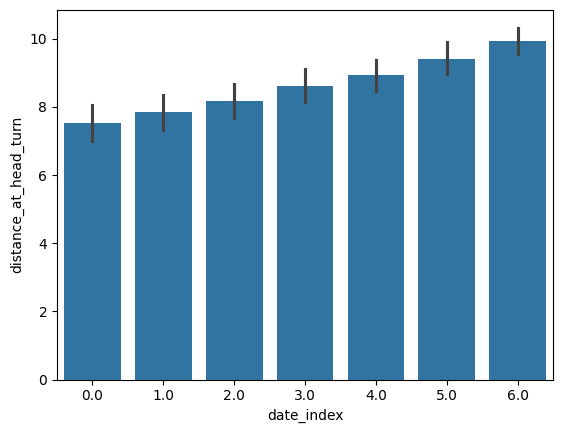

In [252]:
sns.barplot(data = light[(light.intial_lateral_error<=-3)&(light.distance_at_head_turn>=0)],x = 'date_index',y = 'distance_at_head_turn')

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

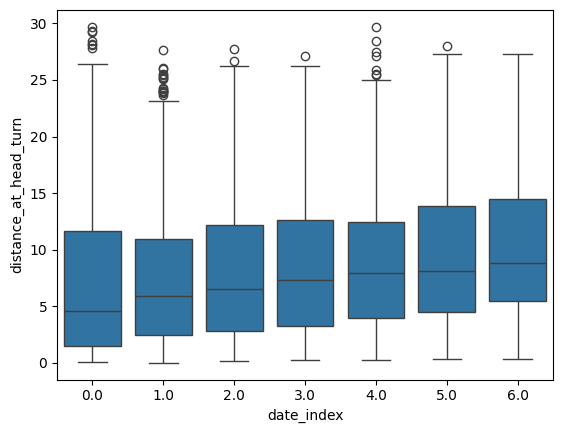

In [84]:
sns.boxplot(data = light[(light.intial_lateral_error<=-3)&(light.distance_at_head_turn>=0)],x = 'date_index',y = 'distance_at_head_turn')

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

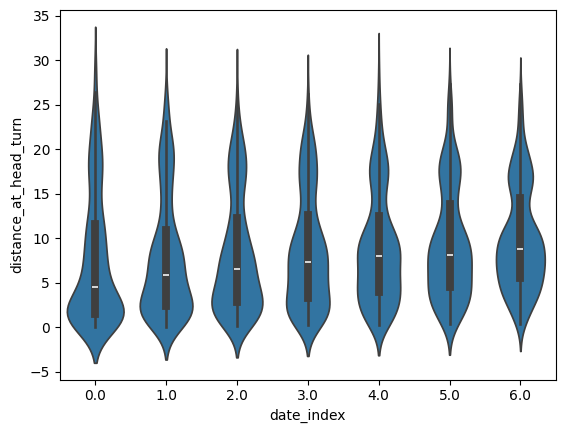

In [87]:
sns.violinplot(data = light[(light.intial_lateral_error<=-3)&(light.distance_at_head_turn>=0)],x = 'date_index',y = 'distance_at_head_turn')

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

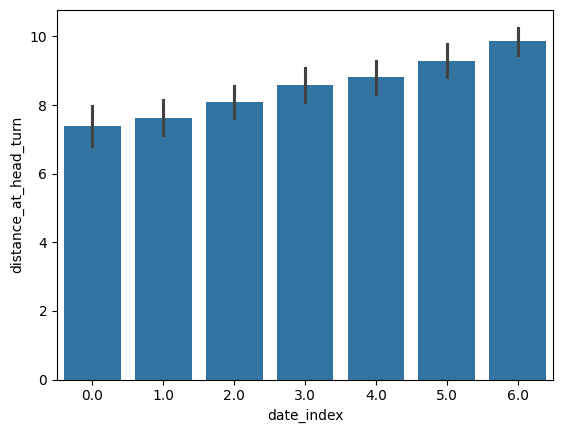

In [79]:
sns.barplot(data = light[light.intial_lateral_error<=-3],x = 'date_index',y = 'distance_at_head_turn')

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

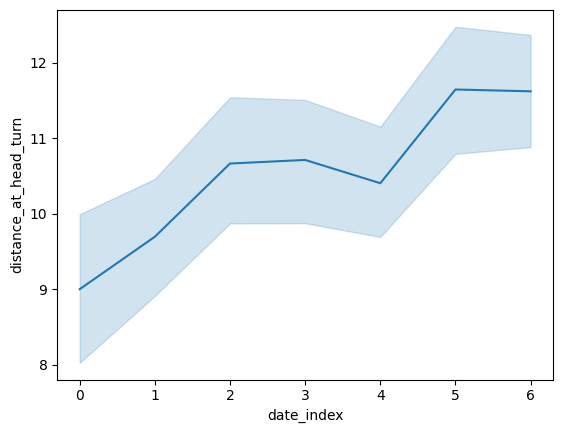

In [275]:
sns.lineplot(data = long[long.intial_lateral_error<=-3],x = 'date_index',y = 'distance_at_head_turn')

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

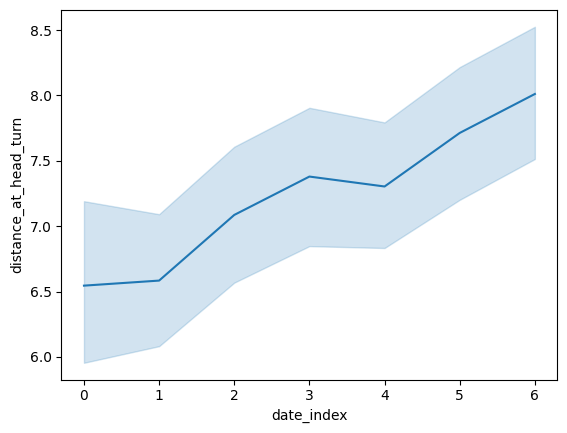

In [254]:
sns.lineplot(data = light[light.avg_lateral_error<=-3],x = 'date_index',y = 'distance_at_head_turn')

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

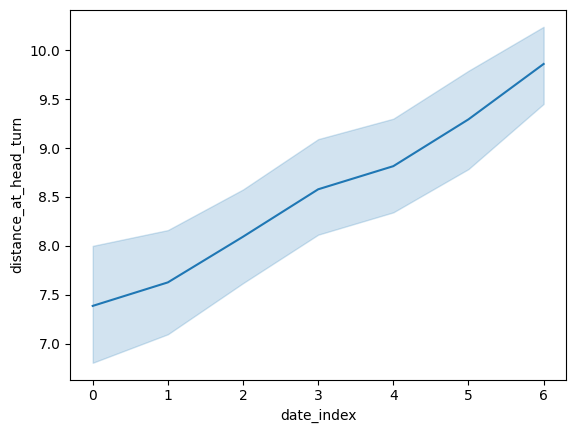

In [76]:
sns.lineplot(data = light[light.intial_lateral_error<=-3],x = 'date_index',y = 'distance_at_head_turn')

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

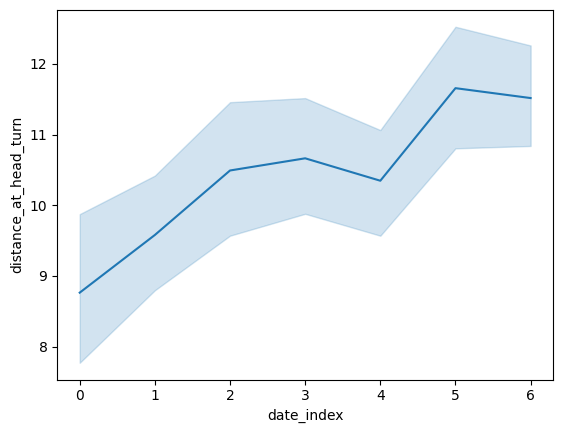

In [69]:
sns.lineplot(data = long[long.intial_lateral_error<=-3],x = 'date_index',y = 'distance_at_head_turn')

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

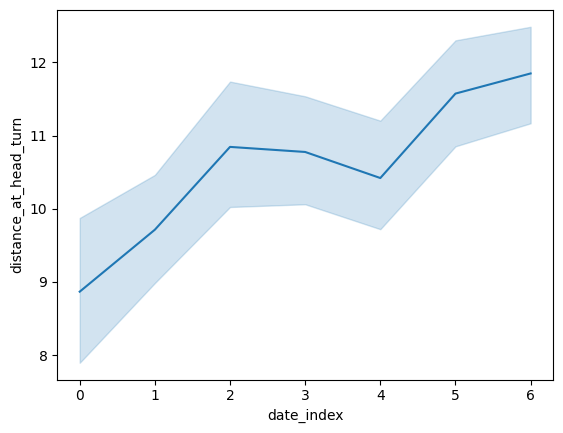

In [88]:
sns.lineplot(data = long,x = 'date_index',y = 'distance_at_head_turn')

In [34]:
light.head_corner_angle_velocity

0        [-64.85788283304537, -114.64204862975454, -140...
1        [-81.78110043153445, -148.65531613175642, -190...
2        [-11.474428814441637, -19.189709627363243, -20...
3        [16.503141822323073, 29.08906654814473, 35.720...
4        [-48.36792870087692, -99.47371760015429, -156....
                               ...                        
13068    [-33.71053790160332, -67.70958498155792, -101....
13069    [-113.39485193021261, -209.7622584354096, -277...
13070    [-33.646456370482696, -61.66925578131739, -80....
13071    [-95.5364007268497, -181.76525287456798, -251....
13072    [-47.154475473555664, -91.47584065977725, -128...
Name: head_corner_angle_velocity, Length: 8884, dtype: object

In [58]:
row.head_corner_angle_velocity[:int(row.obstacle_ind)].min()

-4.376556044232412

In [60]:
row.head_corner_angle_velocity[:int(row.obstacle_ind)].argmin()

19

In [1]:
test = long[long.date_index == 6.0].sample(15)
for ind,row in test.iterrows():
    
        
    fig,ax = plt.subplots(1,3,figsize=(18,5))
    ax[0].set_xticks([])
    ax[0].set_yticks([])
   
    #ax[1].set_xlim(20,0)
    ax[2].invert_xaxis()
    ax[1].invert_xaxis()
   # ax[2].set_xlim(20,0)
    if row.task == 'oadark':
        ax[0].set_facecolor('grey') 
        ax[0].patch.set_alpha(.4)
    else:
        None


    trial_df = test.loc[[ind]]
    plot_arena(test,ax[0])
    plot_orginal_obstacle(trial_df,ax[0],int(row.obstacle_cluster))



    #ax[0].set_title()
   
    ax[1].set_title(row.avg_lateral_error)
    ax[2].set_title('head angle')
   
    #ax[1].set_ylim(-12,2)
    ax[1].set_xlabel('distance to obstacle')
    

  
    ax[0].plot((row.ts_nose_x_cm,row.ts_spine_x_cm),(row.ts_nose_y_cm,row.ts_spine_y_cm),color = 'tab:orange')
    #ax[1].plot(row.ts_distance_from_edge[:int(row.obstacle_ind)],row.head_velocity_at_turn_trace,color = 'tab:orange')
    ax[2].plot( row.ts_distance_from_edge[:int(row.obstacle_ind)],row.head_corner_angle_velocity[:int(row.obstacle_ind)],color = 'tab:orange')
    thresh = row.head_corner_angle_velocity[:int(row.obstacle_ind)].argmin()
    ax[2].scatter(row.ts_distance_from_edge[:int(row.obstacle_ind)][thresh],row.head_corner_angle_velocity[:int(row.obstacle_ind)][thresh],c = 'black')
    ax[0].scatter(row.ts_nose_x_cm[:int(row.obstacle_ind)][thresh],row.ts_nose_y_cm[:int(row.obstacle_ind)][thresh],c = 'black')
    ax[1].plot(row.ts_distance_from_edge[:int(row.obstacle_ind)],row.ts_speed[:int(row.obstacle_ind)],color = 'tab:orange')

NameError: name 'long' is not defined

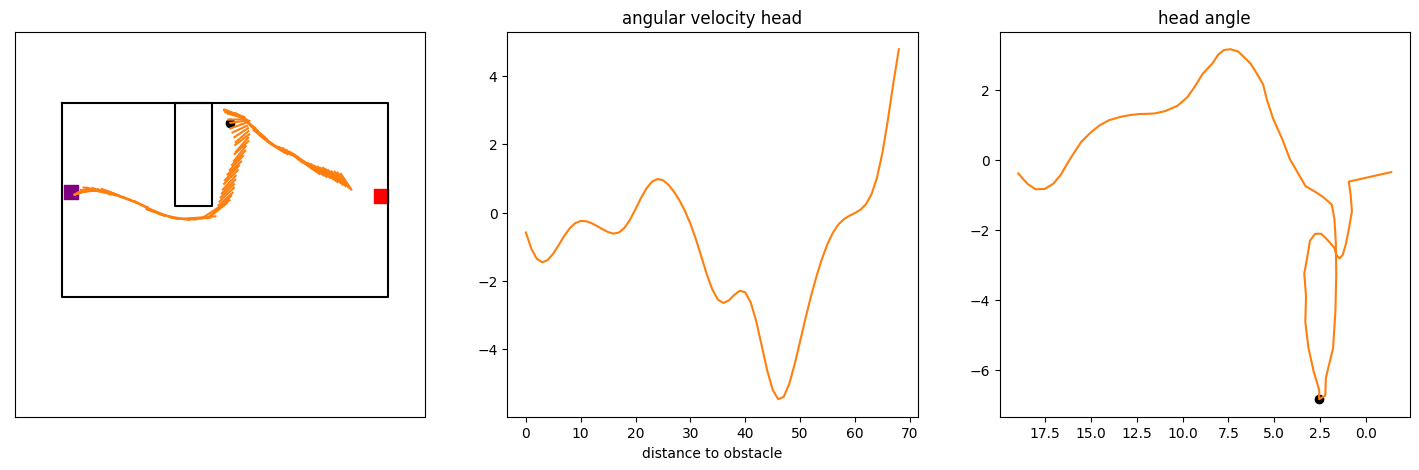

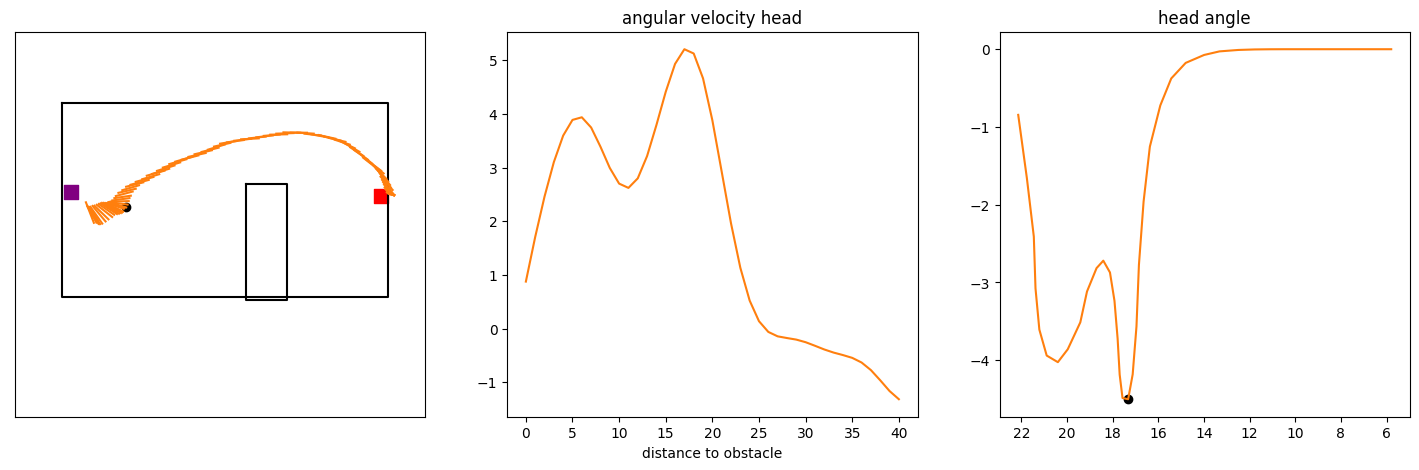

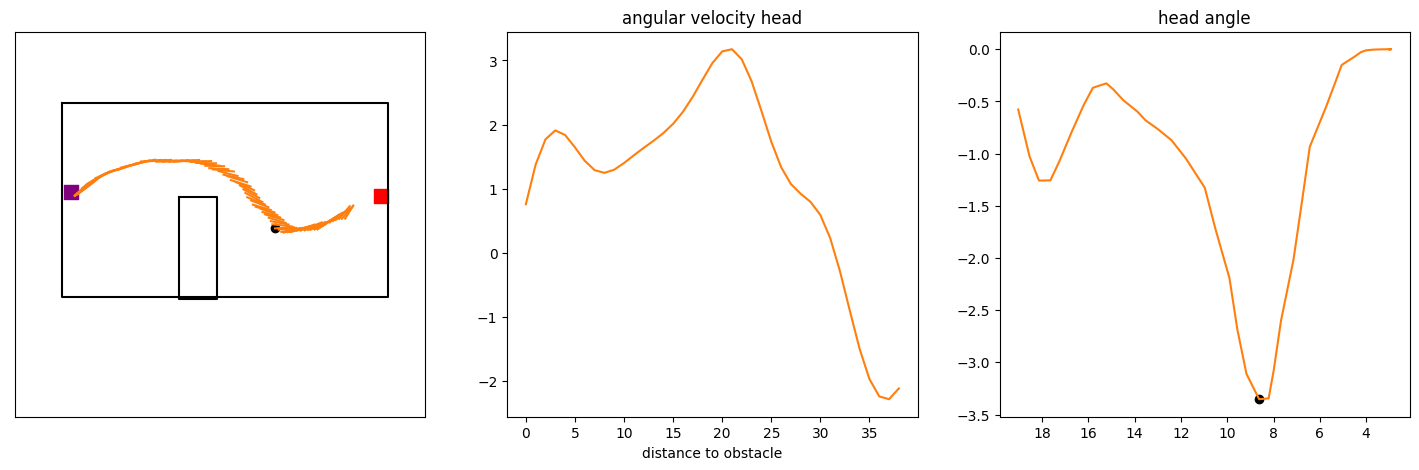

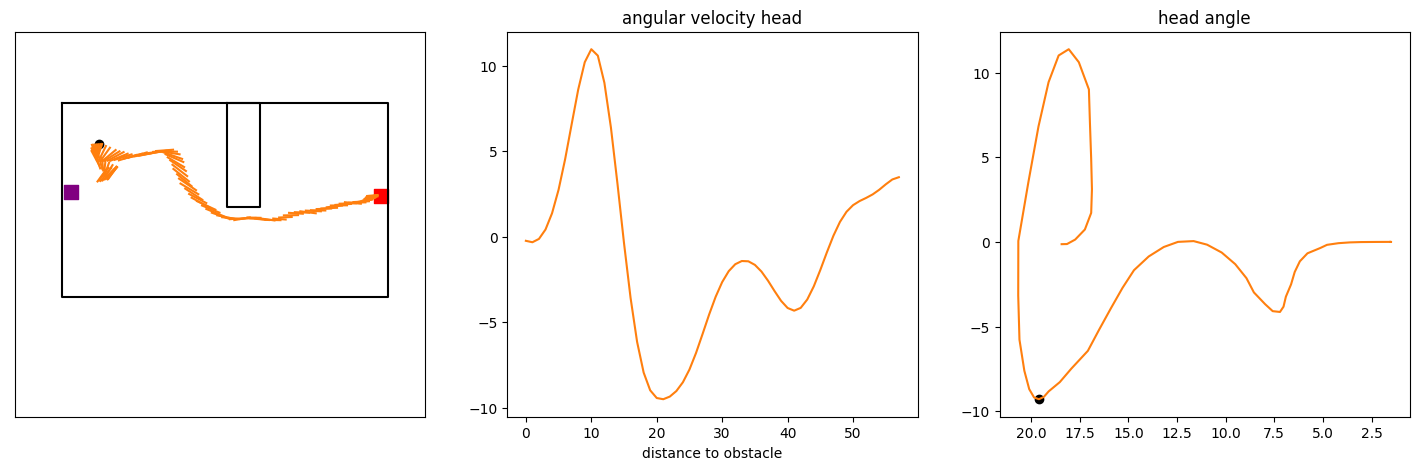

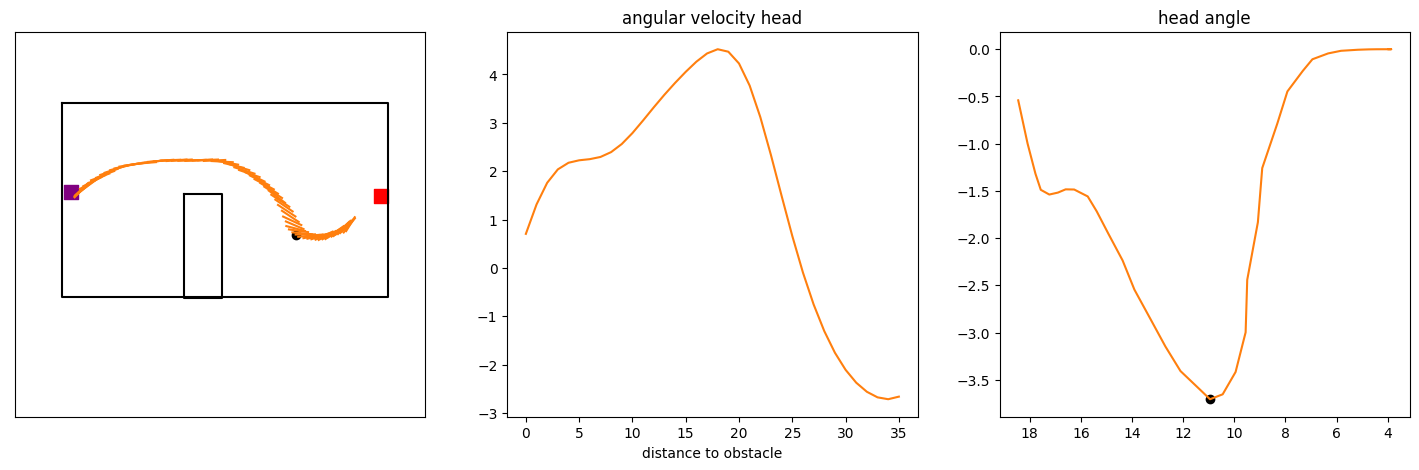

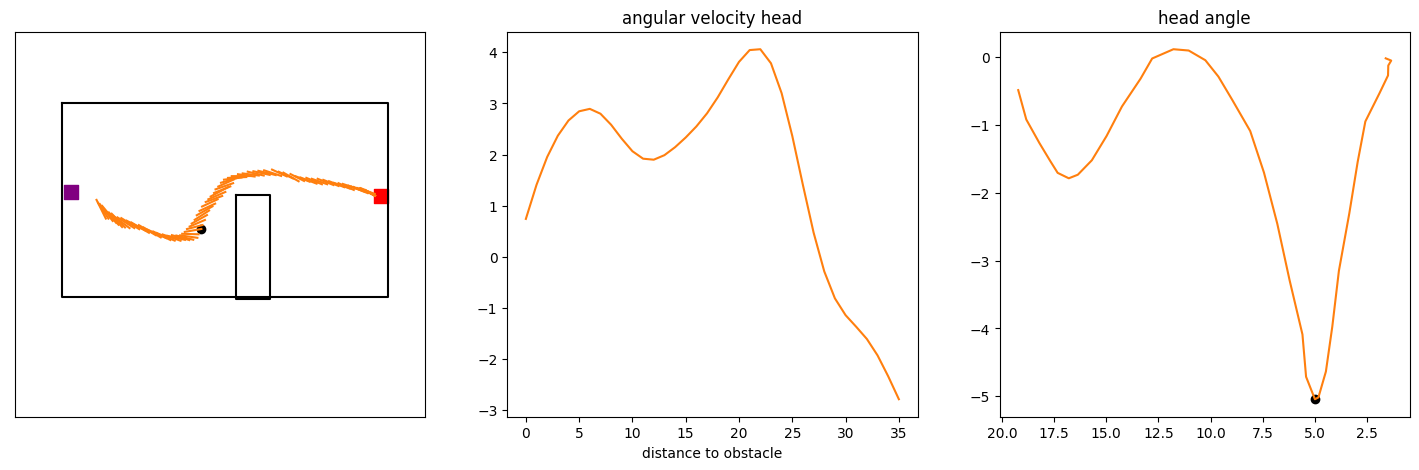

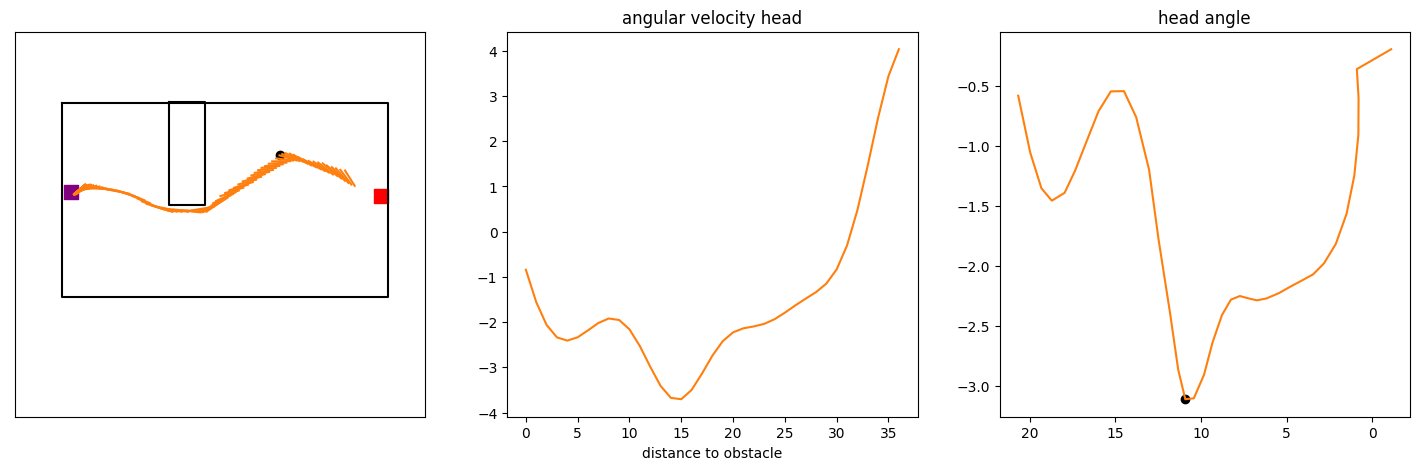

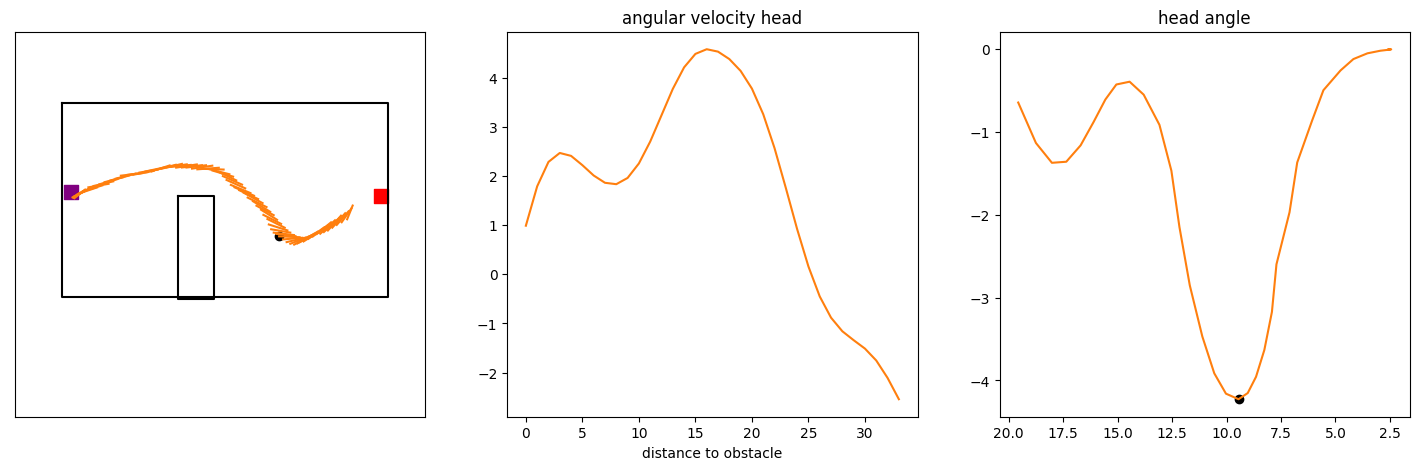

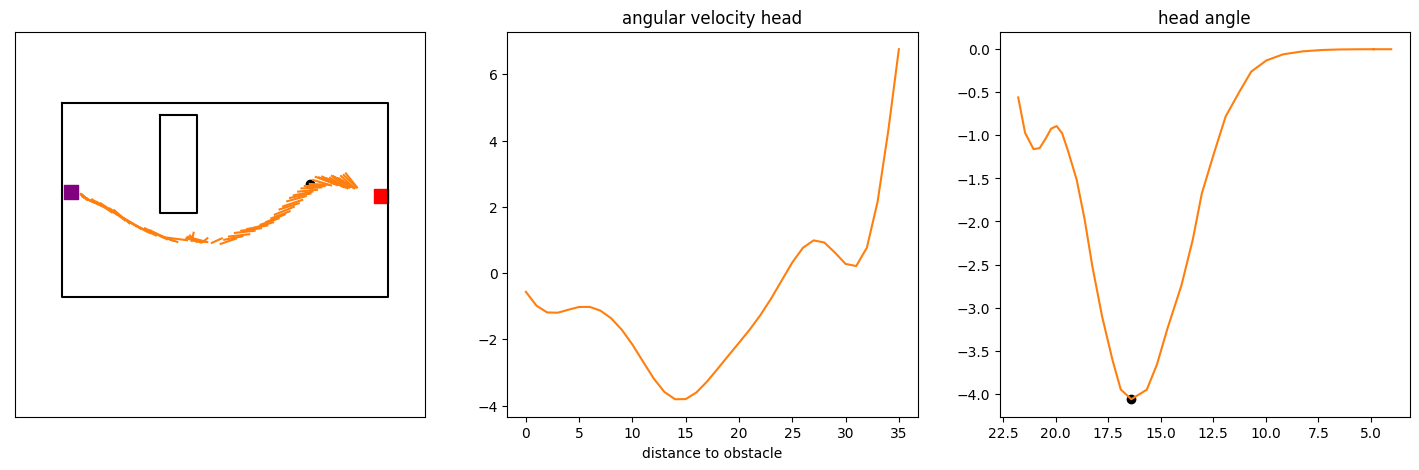

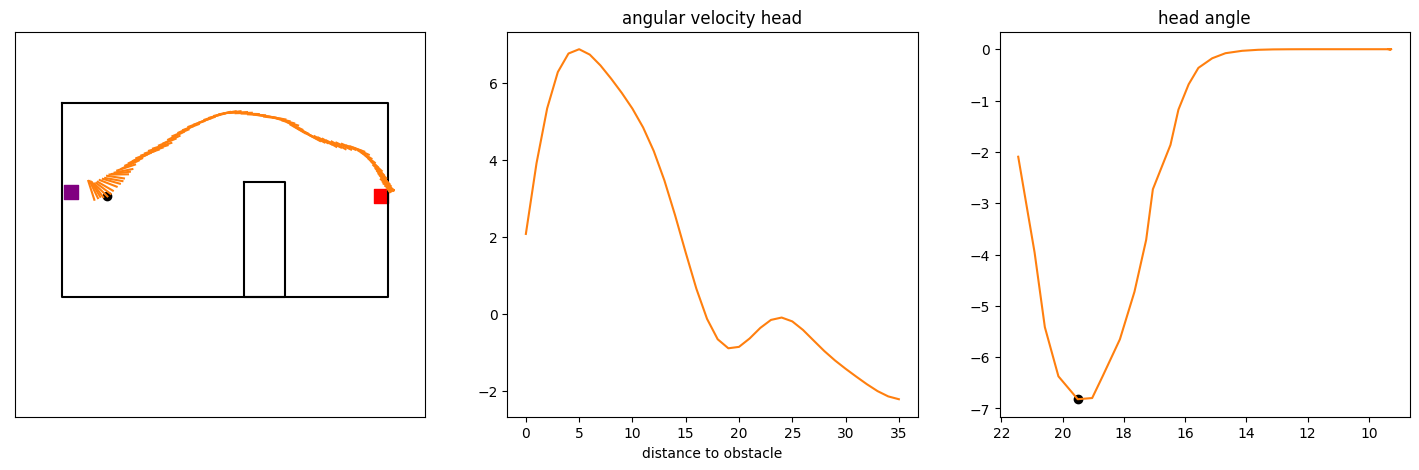

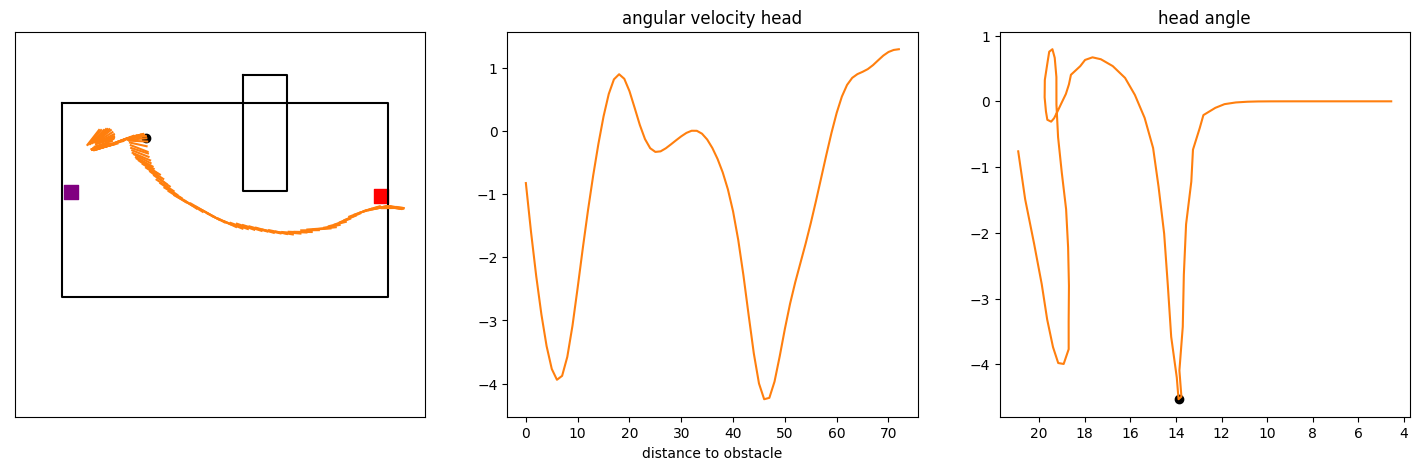

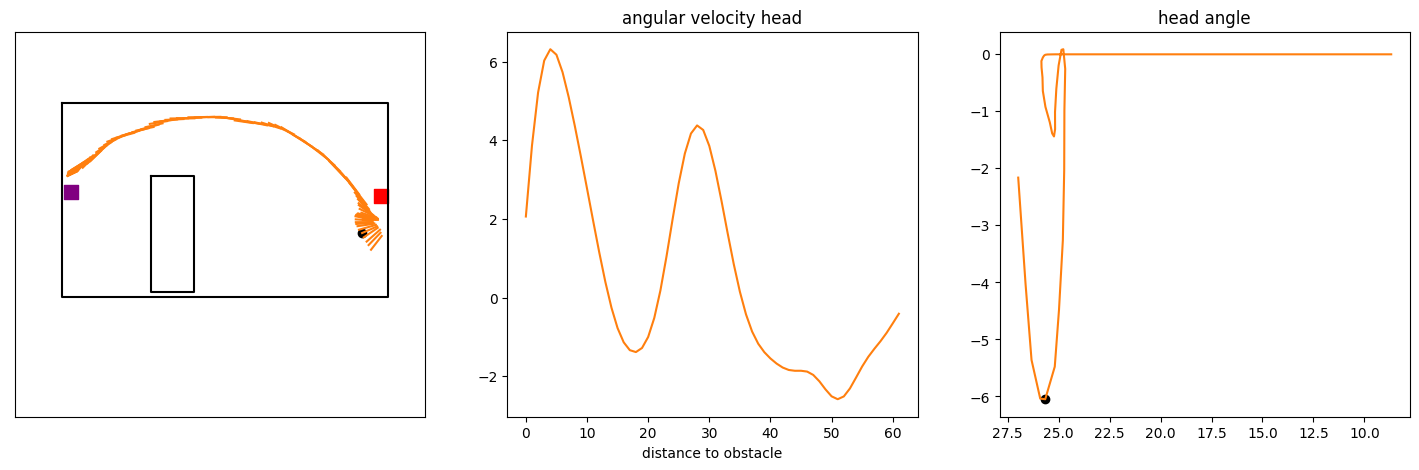

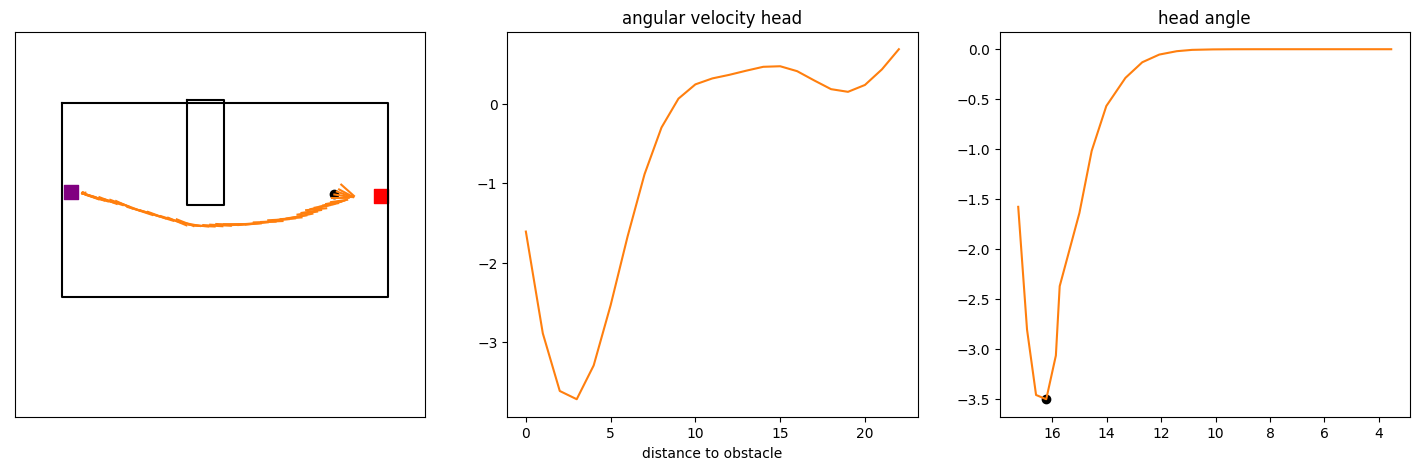

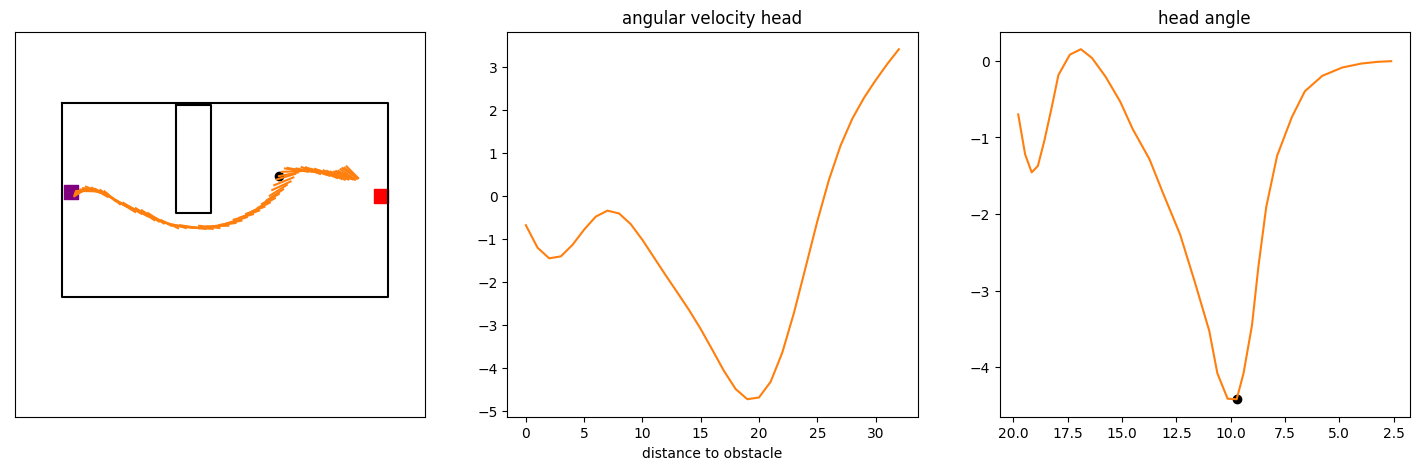

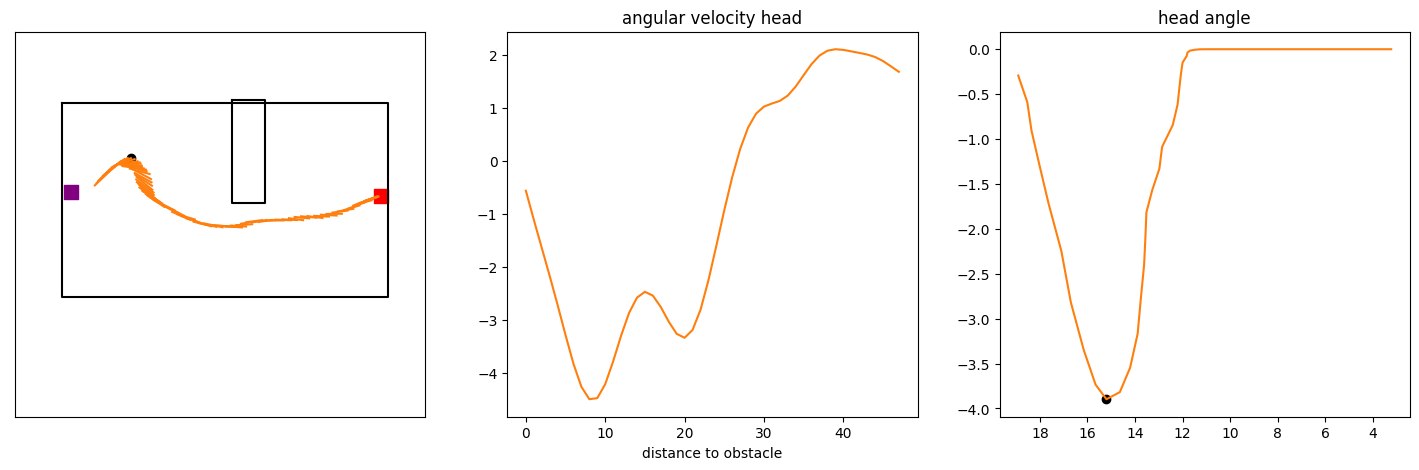

In [273]:
test = long[long.date_index == 6.0].sample(15)
for ind,row in test.iterrows():
    
        
    fig,ax = plt.subplots(1,3,figsize=(18,5))
    ax[0].set_xticks([])
    ax[0].set_yticks([])
   
    #ax[1].set_xlim(20,0)
    ax[2].invert_xaxis()
   # ax[2].set_xlim(20,0)
    if row.task == 'oadark':
        ax[0].set_facecolor('grey') 
        ax[0].patch.set_alpha(.4)
    else:
        None


    trial_df = test.loc[[ind]]
    plot_arena(test,ax[0])
    plot_orginal_obstacle(trial_df,ax[0],int(row.obstacle_cluster))



    #ax[0].set_title()
   
    ax[1].set_title('angular velocity head')
    ax[2].set_title('head angle')
   
    #ax[1].set_ylim(-12,2)
    ax[1].set_xlabel('distance to obstacle')
    

  
    ax[0].plot((row.ts_nose_x_cm,row.ts_spine_x_cm),(row.ts_nose_y_cm,row.ts_spine_y_cm),color = 'tab:orange')
    #ax[1].plot(row.ts_distance_from_edge[:int(row.obstacle_ind)],row.head_velocity_at_turn_trace,color = 'tab:orange')
    ax[2].plot( row.ts_distance_from_edge[:int(row.obstacle_ind)],row.head_corner_angle_velocity[:int(row.obstacle_ind)],color = 'tab:orange')
    thresh = row.head_corner_angle_velocity[:int(row.obstacle_ind)].argmin()
    ax[2].scatter(row.ts_distance_from_edge[:int(row.obstacle_ind)][thresh],row.head_corner_angle_velocity[:int(row.obstacle_ind)][thresh],c = 'black')
    ax[0].scatter(row.ts_nose_x_cm[:int(row.obstacle_ind)][thresh],row.ts_nose_y_cm[:int(row.obstacle_ind)][thresh],c = 'black')
    ax[1].plot(row.head_angle_velocity[:int(row.obstacle_ind)],color = 'tab:orange')


In [40]:
row.ts_distance_from_corner

AttributeError: 'Series' object has no attribute 'ts_distance_from_corner'

In [103]:
light.time

0        4.933333
1        6.250000
2        4.283333
3        6.166667
4        3.050000
           ...   
13068    2.733333
13069    3.350000
13070    3.866667
13071    3.400000
13072    3.500000
Name: time, Length: 8881, dtype: float64

<AxesSubplot: xlabel='date_index', ylabel='intial_lateral_error'>

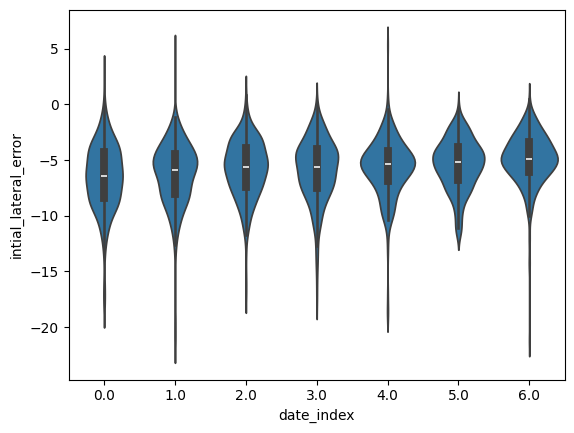

In [135]:
sns.violinplot(data = long,x = 'date_index',y ='intial_lateral_error')

<AxesSubplot: xlabel='date_index', ylabel='time'>

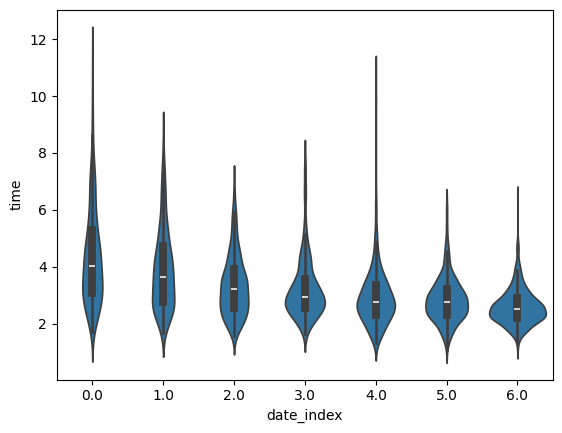

In [274]:
sns.violinplot(data = long,x = 'date_index',y ='time')

<AxesSubplot: ylabel='distance_at_head_turn'>

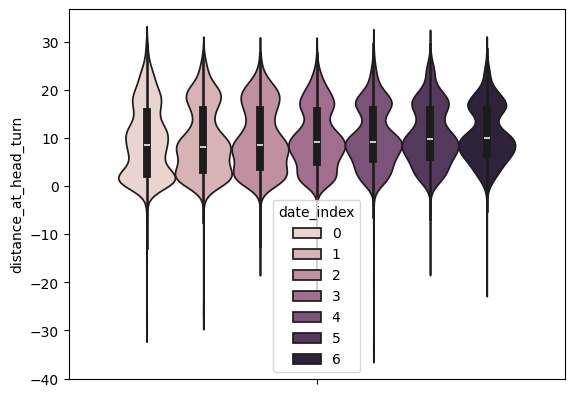

In [24]:
sns.violinplot(data = light,y ='distance_at_head_turn',hue='date_index')

<AxesSubplot: xlabel='distance_at_head_turn', ylabel='Probability'>

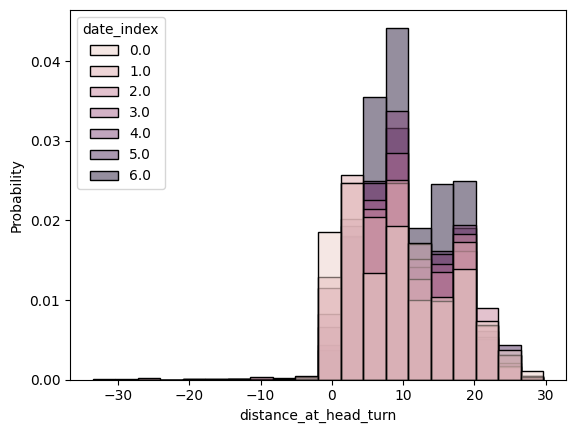

In [22]:
sns.histplot(data = light,x ='distance_at_head_turn',stat='probability',bins = 20,hue='date_index',multiple='layer')

(0.0, 0.4)

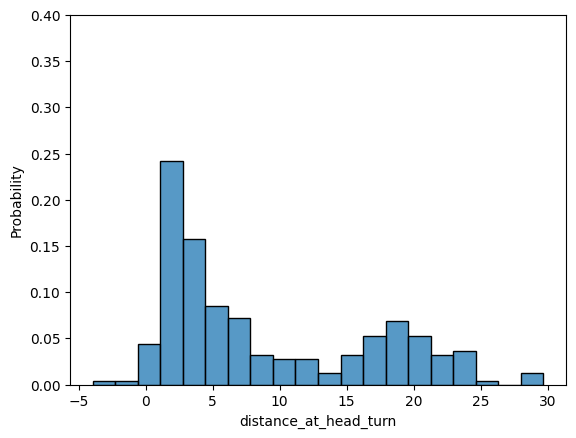

In [140]:
sns.histplot(data = long[long.date_index == 0],x ='distance_at_head_turn',stat='probability',bins = 20)
plt.ylim(0,.4)

<AxesSubplot: xlabel='distance_at_head_turn', ylabel='intial_lateral_error'>

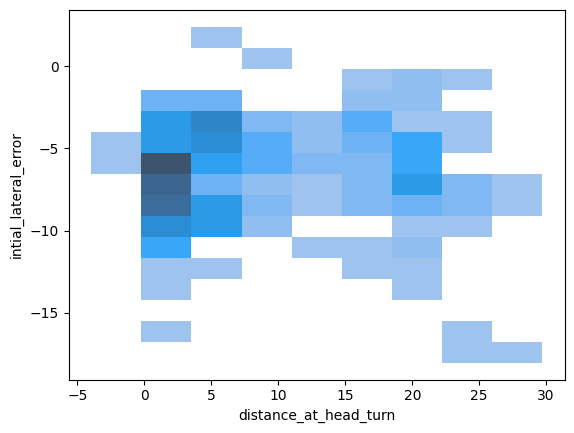

In [25]:
sns.histplot(data = long[long.date_index == 0],x ='distance_at_head_turn',y ='intial_lateral_error')
#plt.ylim(0,.4)

<AxesSubplot: xlabel='distance_at_head_turn', ylabel='intial_lateral_error'>

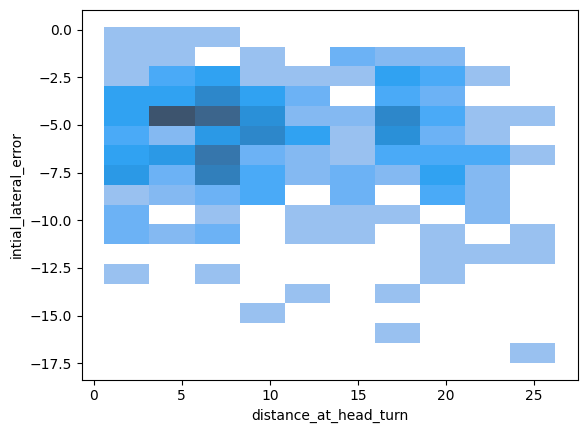

In [147]:
sns.histplot(data = long[long.date_index == 3],x ='distance_at_head_turn',y ='intial_lateral_error')


<AxesSubplot: xlabel='distance_at_head_turn', ylabel='intial_lateral_error'>

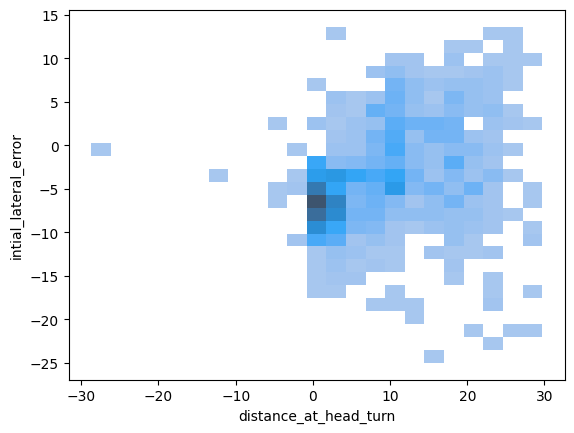

In [149]:
sns.histplot(data = light[light.date_index == 0],x ='distance_at_head_turn',y ='intial_lateral_error')

<AxesSubplot: xlabel='distance_at_head_turn', ylabel='intial_lateral_error'>

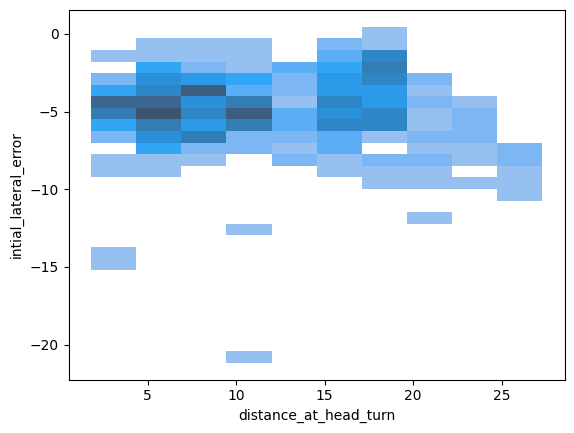

In [26]:
sns.histplot(data = long[long.date_index == 6],x ='distance_at_head_turn',y ='intial_lateral_error')

<AxesSubplot: xlabel='distance_at_head_turn', ylabel='intial_lateral_error'>

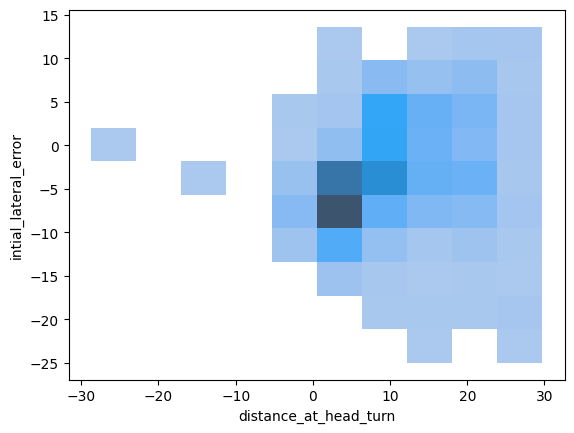

In [155]:
sns.histplot(data = light[light.date_index == 0],x ='distance_at_head_turn',y ='intial_lateral_error',bins=10)

(-10.0, 20.0)

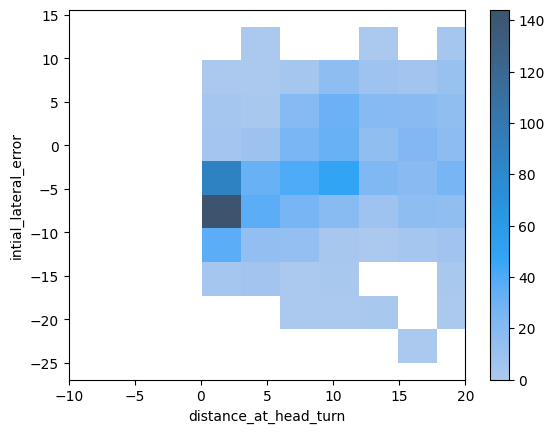

In [165]:
sns.histplot(data = light[(light.date_index == 0) &(light.distance_at_head_turn >= 0) ],x ='distance_at_head_turn',y ='intial_lateral_error',bins=10,cbar=True)
plt.xlim(-10,20)

(-25.0, 10.0)

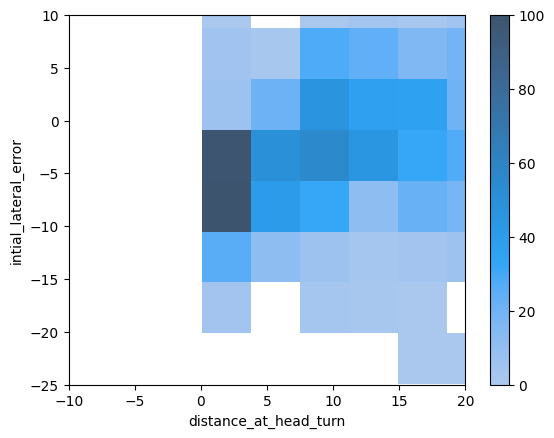

In [197]:
ax = sns.histplot(data = light[(light.date_index == 0) &(light.distance_at_head_turn >= 0) ],x ='distance_at_head_turn',y ='intial_lateral_error',bins=8,cbar=True)
ax.collections[0].set_clim(0,100) 
plt.xlim(-10,20)
plt.ylim(-25,10)

In [206]:
array.shape

(12, 14)

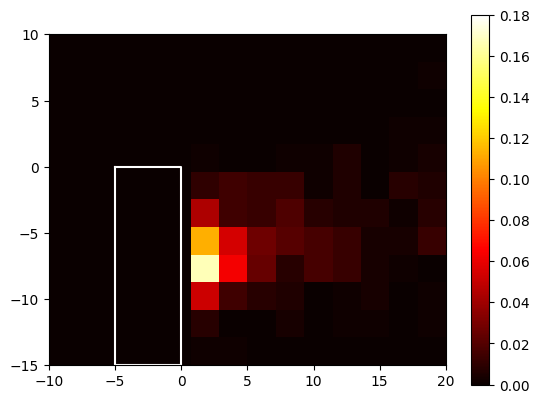

In [232]:
data = pd.concat([long,short])
data = data[(data.date_index == 0)&(light.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -15,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

plt.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

plt.plot( [-5,0,0,-5,-5], [0,0,-15,-15,0],c ='white')
plt.colorbar()

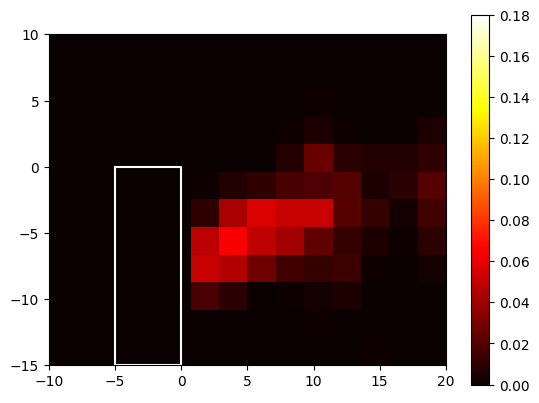

In [222]:
data = pd.concat([long,short])
data = data[(data.date_index == 4)&(light.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -15,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

plt.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

plt.plot( [-5,0,0,-5,-5], [0,0,-15,-15,0],c ='white')
plt.colorbar()

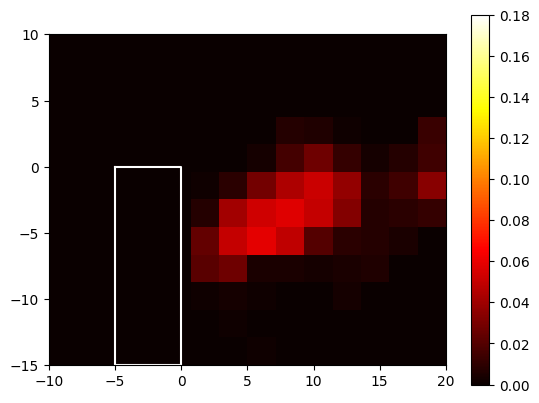

In [225]:
data = pd.concat([long,short])
data = data[(data.date_index == 6)&(light.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -15,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

plt.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

plt.plot( [-5,0,0,-5,-5], [0,0,-15,-15,0],c ='white')
plt.colorbar()

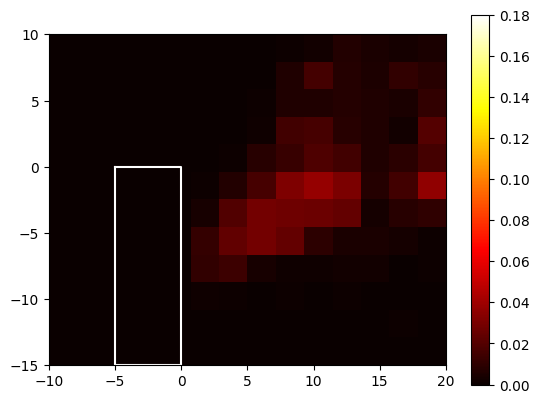

In [229]:
data = light
data = data[(data.date_index == 6)&(light.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -15,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

plt.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

plt.plot( [-5,0,0,-5,-5], [0,0,-15,-15,0],c ='white')
plt.colorbar()

(-15.0, 10.0)

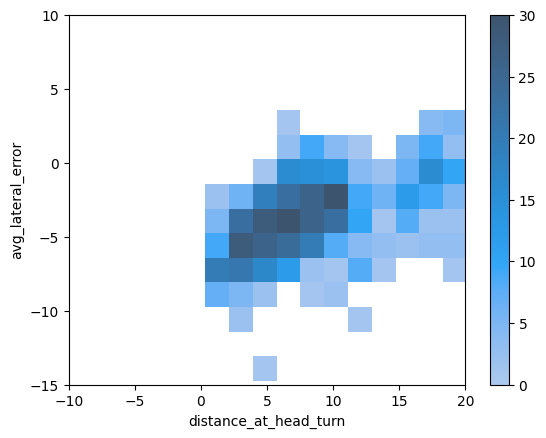

In [129]:
data = pd.concat([long,short])
ax = sns.histplot(data = data[(data.date_index == 6)&(light.distance_at_head_turn >= 0) ],x ='distance_at_head_turn',y ='avg_lateral_error',bins=15,cbar=True)
ax.collections[0].set_clim(0,30) 
plt.xlim(-10,20)
plt.ylim(-15,10)

(-15.0, 10.0)

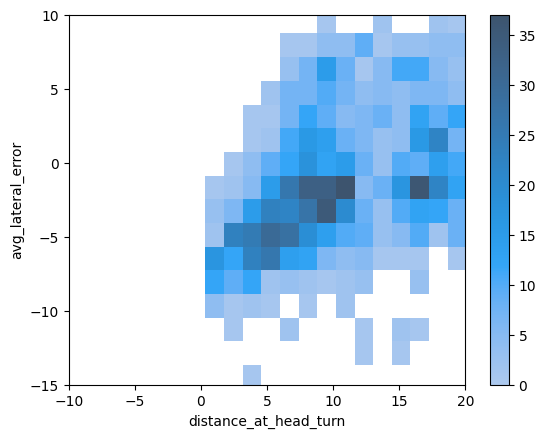

In [79]:
ax = sns.histplot(data = light[(light.date_index == 6) &(light.distance_at_head_turn >= 0) ],x ='distance_at_head_turn',y ='avg_lateral_error',bins=20,cbar=True)
#ax.collections[0].set_clim(0,100) 
plt.xlim(-10,20)
plt.ylim(-15,10)

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

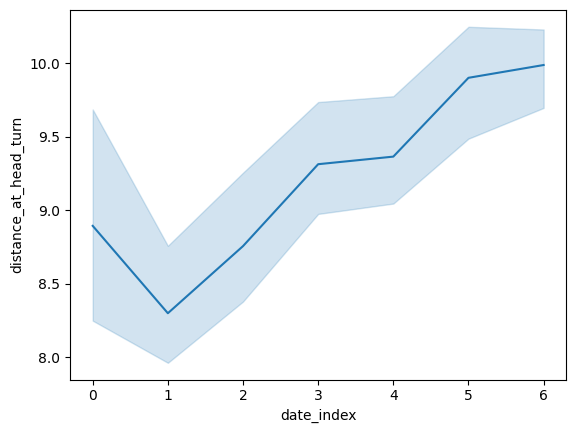

In [150]:
sns.lineplot(data = light[(light.distance_at_head_turn >= 0) ],x ='date_index',y ='distance_at_head_turn',estimator='median')

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

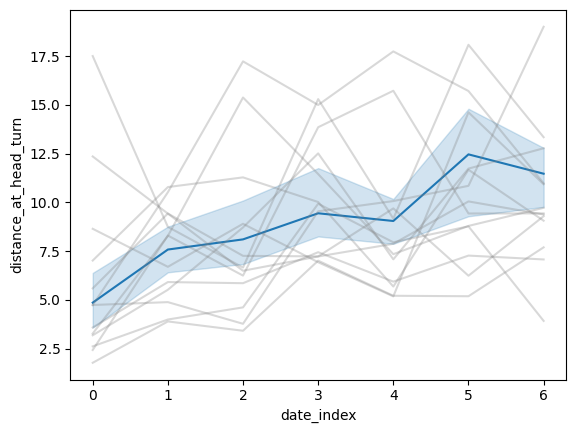

In [268]:
palette = sns.color_palette(['grey'], len(long['animal'].unique()))
sns.lineplot(data = long[(long.intial_lateral_error<=-5)&(long.distance_at_head_turn >= 0) ],x = 'date_index',y = 'distance_at_head_turn',estimator='median')
sns.lineplot(data=long[(long.intial_lateral_error<=-5)],x='date_index',y='distance_at_head_turn',estimator='median',hue ='animal',legend=False,palette = palette,ci =None,alpha = .3)

<AxesSubplot: xlabel='date_index', ylabel='avg_lateral_error'>

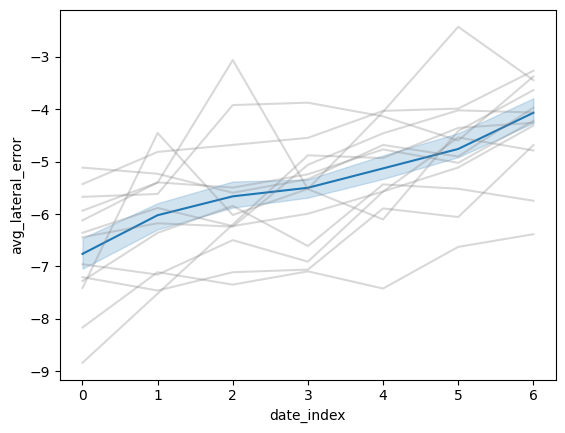

In [230]:
palette = sns.color_palette(['grey'], len(light['animal'].unique()))
data = pd.concat([long,short])
sns.lineplot(data = data[(data.avg_lateral_error<=0)&(data.distance_at_head_turn >= 0) ],x = 'date_index',y = 'avg_lateral_error',estimator='median')
sns.lineplot(data=data[(data.avg_lateral_error<=0)&(data.distance_at_head_turn >= 0) ],x='date_index',y='avg_lateral_error',estimator='median',hue ='animal',legend=False,palette = palette,ci =None,alpha = .3)

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

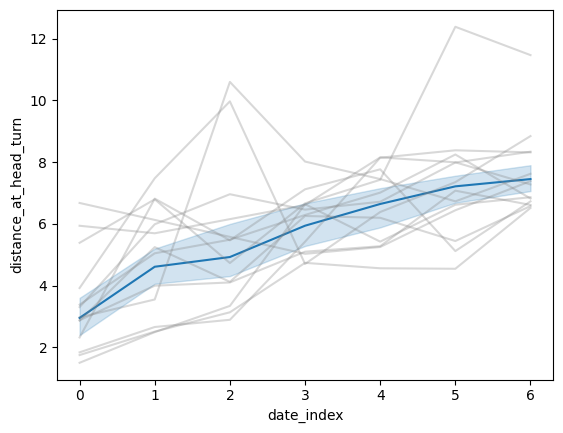

In [231]:
palette = sns.color_palette(['grey'], len(light['animal'].unique()))
data = pd.concat([long,short])
sns.lineplot(data = data[(data.avg_lateral_error<=0)&(data.distance_at_head_turn >= 0) ],x = 'date_index',y = 'distance_at_head_turn',estimator='median')
sns.lineplot(data=data[(data.avg_lateral_error<=0)&(data.distance_at_head_turn >= 0) ],x='date_index',y='distance_at_head_turn',estimator='median',hue ='animal',legend=False,palette = palette,ci =None,alpha = .3)

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

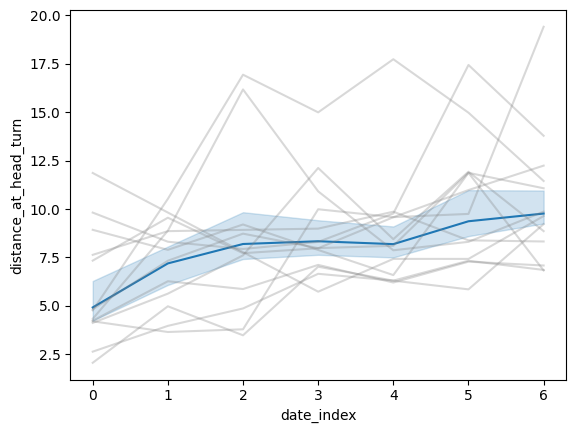

In [105]:
palette = sns.color_palette(['grey'], len(long['animal'].unique()))
sns.lineplot(data = long[(long.avg_lateral_error<=0)&(long.distance_at_head_turn >= 0) ],x = 'date_index',y = 'distance_at_head_turn',estimator='median')
sns.lineplot(data=long[(long.avg_lateral_error<=0)&(long.distance_at_head_turn >= 0) ],x='date_index',y='distance_at_head_turn',estimator='median',hue ='animal',legend=False,palette = palette,ci =None,alpha = .3)

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

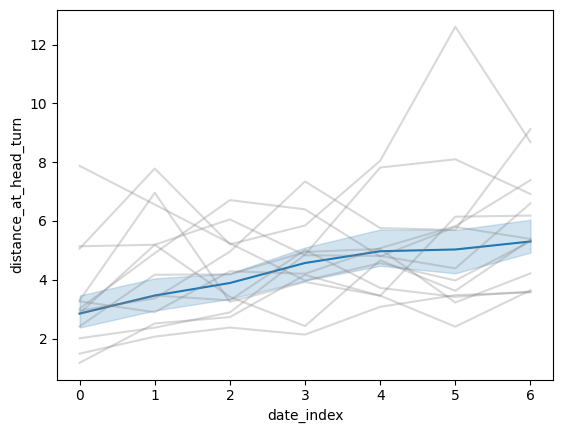

In [104]:
palette = sns.color_palette(['grey'], len(light['animal'].unique()))
sns.lineplot(data = light[(light.avg_lateral_error<=-5)&(light.distance_at_head_turn >= 0) ],x = 'date_index',y = 'distance_at_head_turn',estimator='median')
sns.lineplot(data=light[(light.avg_lateral_error<=-5)&(light.distance_at_head_turn >= 0) ],x='date_index',y='distance_at_head_turn',estimator='median',hue ='animal',legend=False,palette = palette,ci =None,alpha = .3)

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

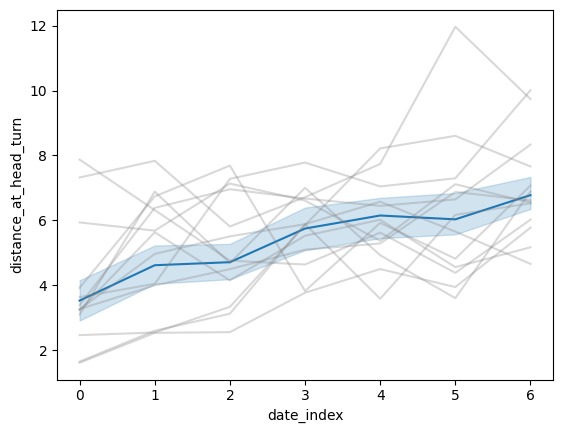

In [102]:
palette = sns.color_palette(['grey'], len(light['animal'].unique()))
sns.lineplot(data = light[(light.avg_lateral_error<=-3)&(light.distance_at_head_turn >= 0) ],x = 'date_index',y = 'distance_at_head_turn',estimator='median')
sns.lineplot(data=light[(light.avg_lateral_error<=-3)&(light.distance_at_head_turn >= 0) ],x='date_index',y='distance_at_head_turn',estimator='median',hue ='animal',legend=False,palette = palette,ci =None,alpha = .3)

<AxesSubplot: xlabel='date_index', ylabel='avg_lateral_error'>

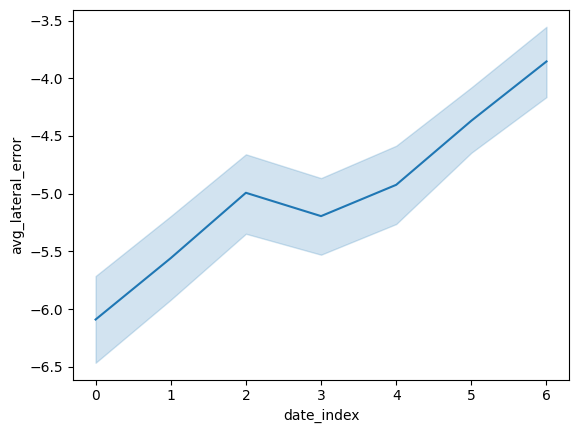

In [101]:
sns.lineplot(data = long[(long.distance_at_head_turn >= 0) ],x ='date_index',y ='avg_lateral_error')

<AxesSubplot: xlabel='date_index', ylabel='distance_at_head_turn'>

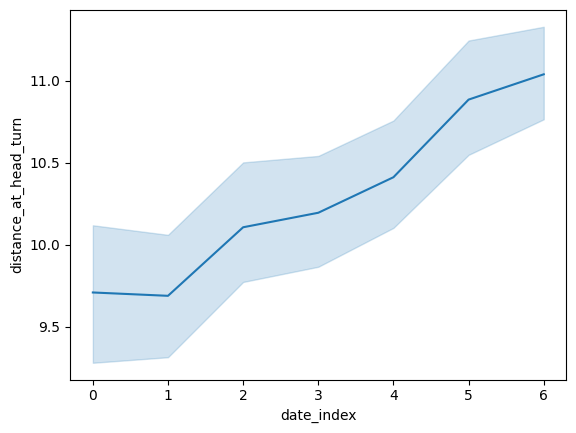

In [86]:
sns.lineplot(data = light[(light.distance_at_head_turn >= 0) ],x ='date_index',y ='distance_at_head_turn')

<AxesSubplot: xlabel='date_index', ylabel='linearity'>

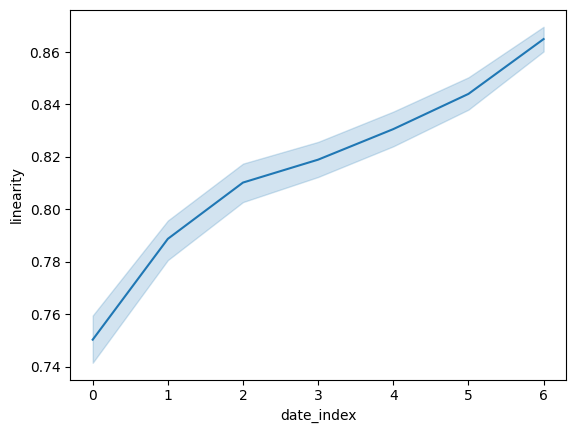

In [272]:
sns.lineplot(data = light[(light.distance_at_head_turn >= 0) ],x ='date_index',y ='linearity')

<AxesSubplot: xlabel='date_index', ylabel='tortuosity'>

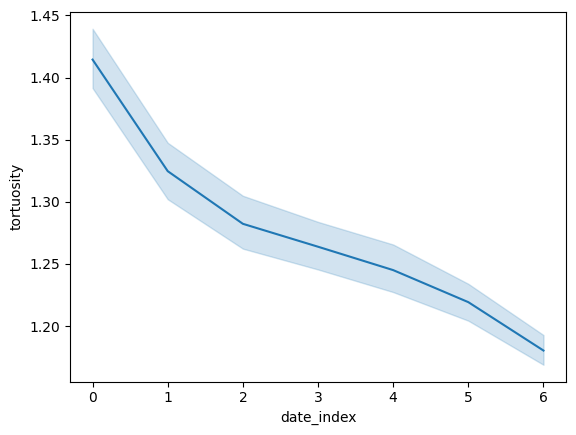

In [271]:
sns.lineplot(data = light[(light.distance_at_head_turn >= 0) ],x ='date_index',y ='tortuosity')

<AxesSubplot: xlabel='date_index', ylabel='avg_lateral_error'>

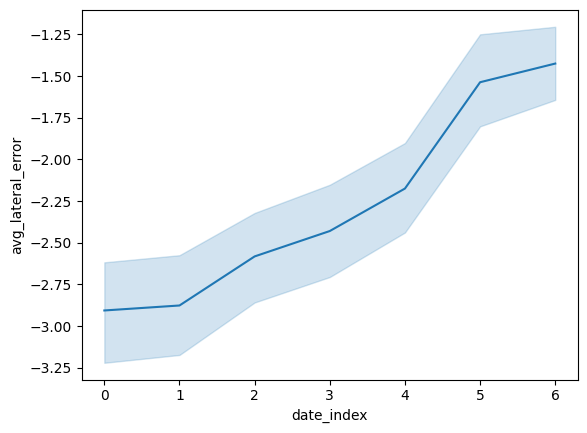

In [50]:
sns.lineplot(data = light[(light.distance_at_head_turn >= 0) ],x ='date_index',y ='avg_lateral_error')

<AxesSubplot: xlabel='date_index', ylabel='intial_lateral_error'>

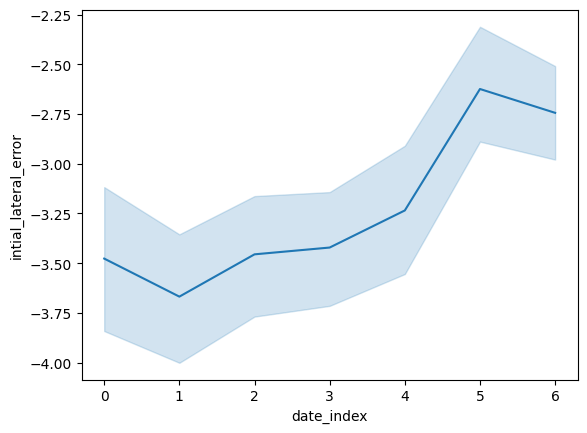

In [185]:
sns.lineplot(data = light[(light.distance_at_head_turn >= 0) ],x ='date_index',y ='intial_lateral_error')

<AxesSubplot: xlabel='distance_at_head_turn', ylabel='Probability'>

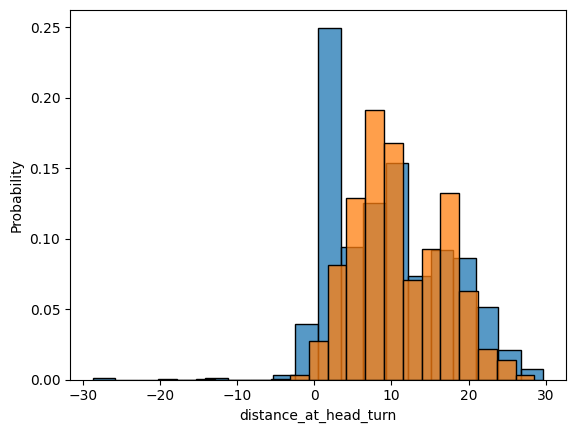

In [205]:
sns.histplot(data = light[light.date_index == 0],x ='distance_at_head_turn',stat='probability',bins = 20)
sns.histplot(data = light[light.date_index == 6],x ='distance_at_head_turn',stat='probability',bins = 20)

<AxesSubplot: xlabel='distance_at_head_turn', ylabel='Probability'>

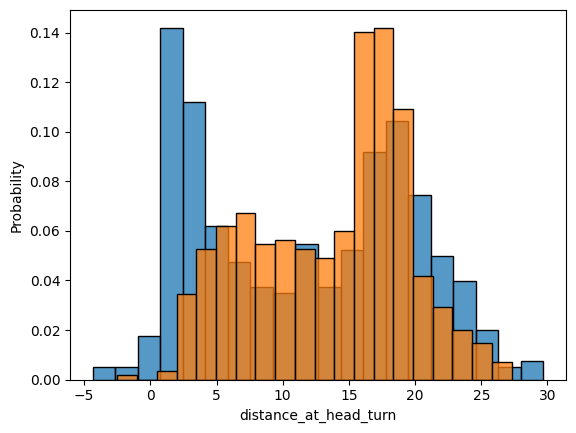

In [263]:
sns.histplot(data = long[long.date_index == 0],x ='distance_at_head_turn',stat='probability',bins = 20)
sns.histplot(data = long[long.date_index == 6],x ='distance_at_head_turn',stat='probability',bins = 20)

<AxesSubplot: xlabel='distance_at_head_turn', ylabel='Probability'>

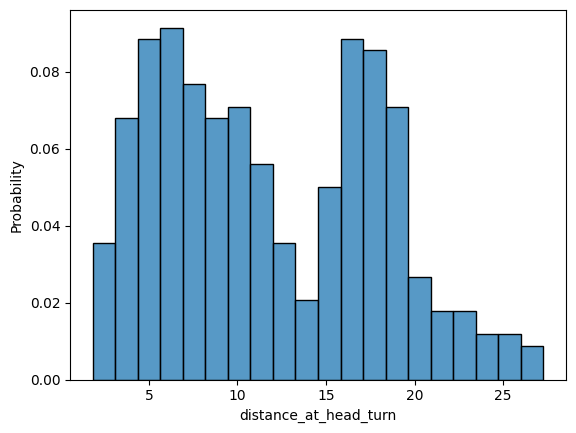

In [202]:
sns.histplot(data = long[long.date_index == 6],x ='distance_at_head_turn',stat='probability',bins = 20)

<AxesSubplot: xlabel='intial_lateral_error', ylabel='Probability'>

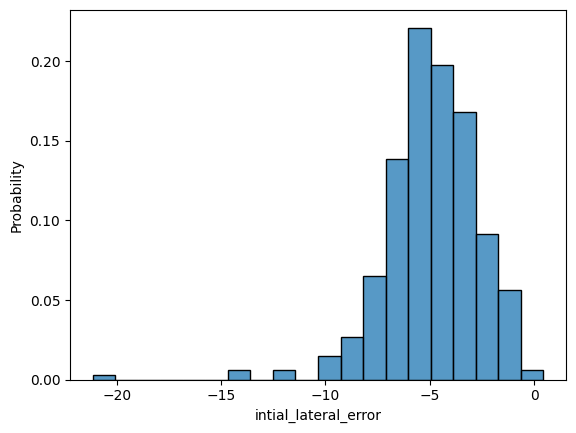

In [132]:
sns.histplot(data = long[long.date_index == 6],x ='intial_lateral_error',stat='probability',bins = 20)

<AxesSubplot: xlabel='intial_lateral_error', ylabel='Probability'>

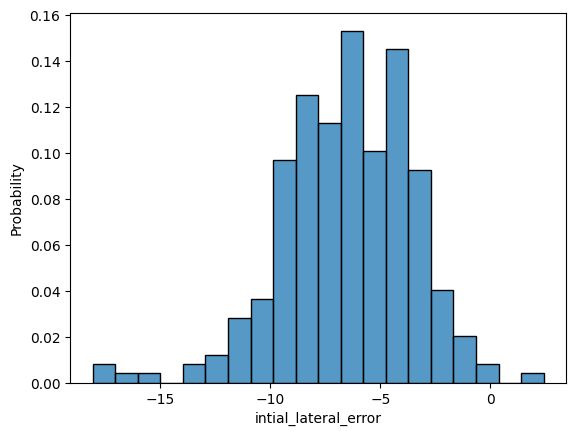

In [133]:
sns.histplot(data = long[long.date_index == 0],x ='intial_lateral_error',stat='probability',bins = 20)

<AxesSubplot: xlabel='date_index', ylabel='intial_lateral_error'>

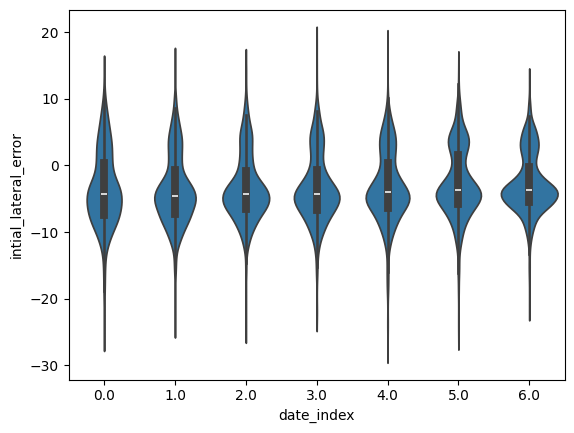

In [118]:
sns.violinplot(data = light,x = 'date_index',y ='intial_lateral_error')

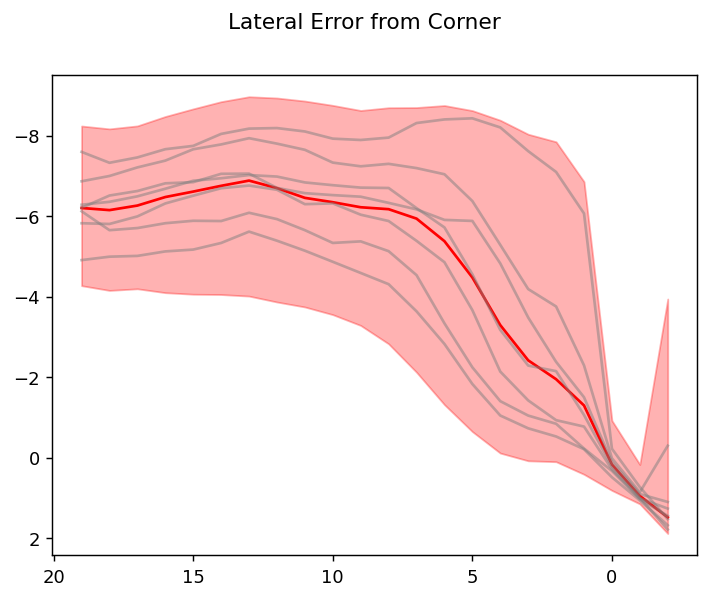

In [234]:

xnew =  np.arange(-2, 20, 1) 
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Lateral Error from Corner')
ax.invert_xaxis()
ax.invert_yaxis()
#ax.set_ylim((0,-10))
df = pd.concat([long,short])
#data = drop_nans_in_columns(data,'obstacle_devations')
df = drop_nans_in_columns(df,'lateral_error')



rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmedian(angle_array,axis = 0)
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')
#symmetrize_y_axis(ax)

for ani,ani_df in df.groupby(['date_index']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmedian(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)
    median, q1, q3, iqr = calculate_quartiles(angle_array)

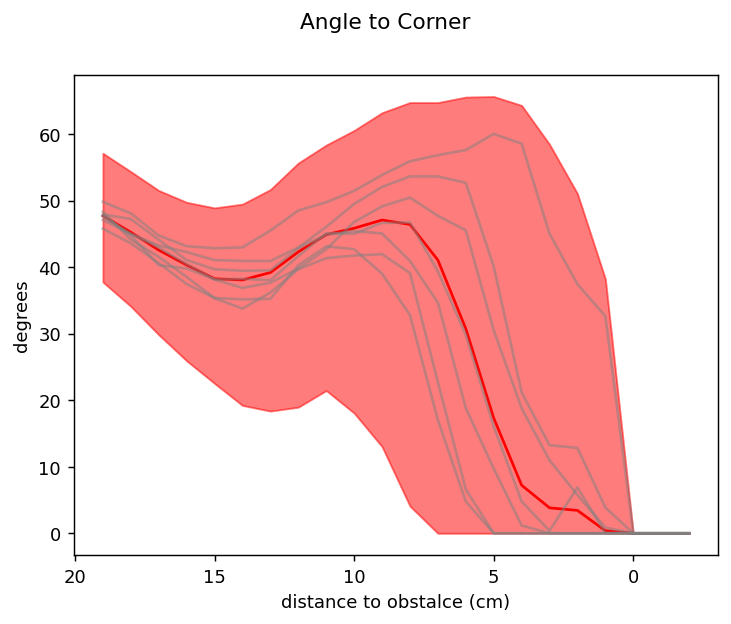

In [246]:
df = pd.concat([long,short])
df = drop_nans_in_columns(df,'obstacle_ind')
fig,ax = plt.subplots(dpi = 130)
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
fig.suptitle('Angle to Corner')
#ax.invert_xaxis()
#ax.invert_xaxis()

xnew =  np.arange(-2, 20, 1) 
xnew= np.flip(xnew)

#xnew= np.flip(xnew)

rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmedian(angle_array,axis = 0)
ax.invert_xaxis()
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, edge_outliers(q1,1.5), edge_outliers(q3,1.5), color='r', alpha=0.3, label='IQR')
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')

for ani,ani_df in df.groupby(['date_index']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmedian(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)
    angle_mean = edge_outliers(angle_mean,1.5)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)

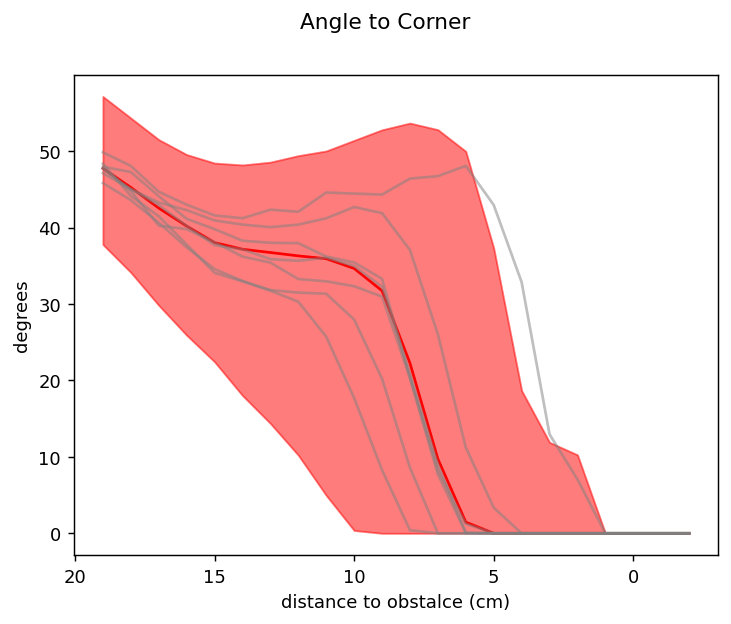

In [238]:
df = long
df = drop_nans_in_columns(df,'obstacle_ind')
fig,ax = plt.subplots(dpi = 130)
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
fig.suptitle('Angle to Corner')
#ax.invert_xaxis()
#ax.invert_xaxis()

xnew =  np.arange(-2, 20, 1) 
xnew= np.flip(xnew)

#xnew= np.flip(xnew)

rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmedian(angle_array,axis = 0)
ax.invert_xaxis()
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, edge_outliers(q1,1.5), edge_outliers(q3,1.5), color='r', alpha=0.3, label='IQR')
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')

for ani,ani_df in df.groupby(['date_index']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmedian(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)
    angle_mean = edge_outliers(angle_mean,1.5)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)

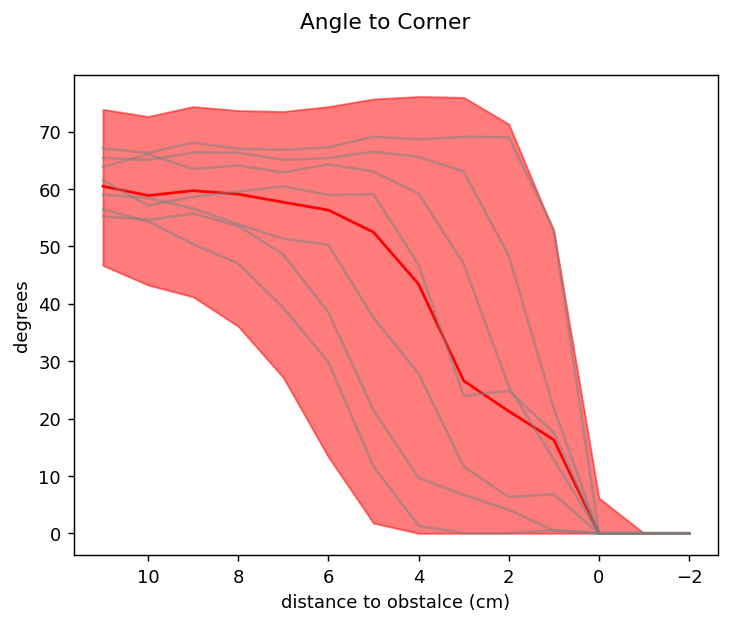

In [242]:
df = short
df = drop_nans_in_columns(df,'obstacle_ind')
fig,ax = plt.subplots(dpi = 130)
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
fig.suptitle('Angle to Corner')
#ax.invert_xaxis()
#ax.invert_xaxis()

xnew =  np.arange(-2, 12, 1) 
xnew= np.flip(xnew)

#xnew= np.flip(xnew)

rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmedian(angle_array,axis = 0)
ax.invert_xaxis()
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, edge_outliers(q1,1.5), edge_outliers(q3,1.5), color='r', alpha=0.3, label='IQR')
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')

for ani,ani_df in df.groupby(['date_index']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmedian(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)
    angle_mean = edge_outliers(angle_mean,1)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)

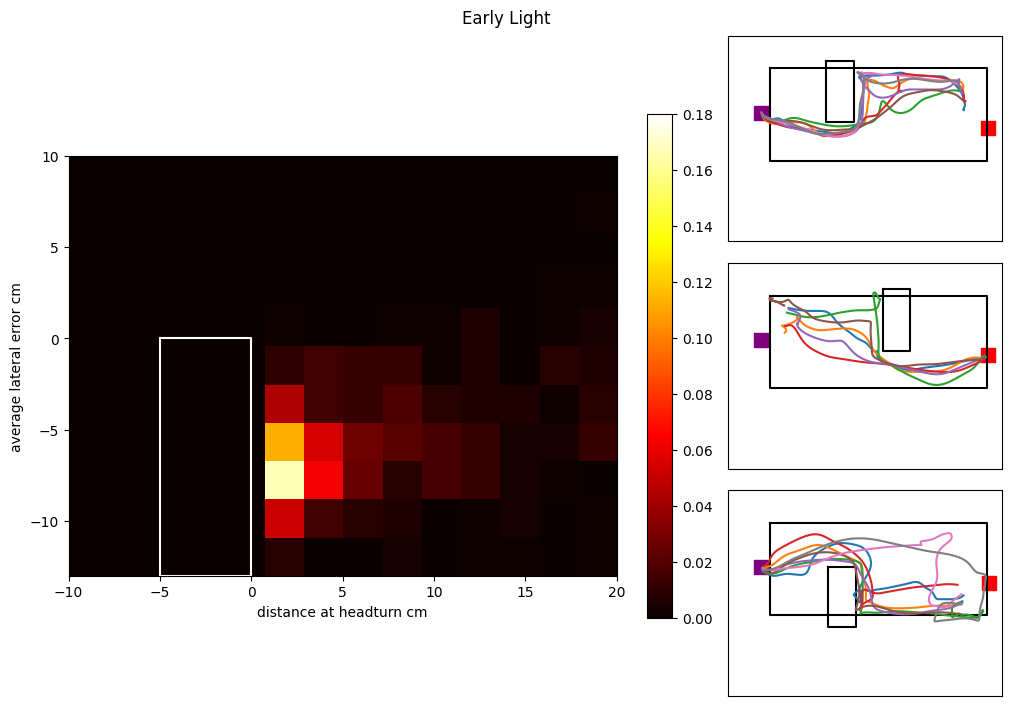

In [267]:


fig = plt.figure(layout = 'constrained',figsize=(10,7))
fig.suptitle('Early Light')

gs = GridSpec(ncols=6, nrows=6,figure=fig)

ax1 = fig.add_subplot(gs[:, :4])
ax1.set_xlabel('distance at headturn cm')
ax1.set_ylabel('average lateral error cm')

data = pd.concat([long,short])
data = data[(data.date_index == 0)&(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

#ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax1.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
fig.colorbar(ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)


ax2 = fig.add_subplot(gs[0:2, 4:])
ax2.set_xticks([])
ax2.set_yticks([])
trace_ax2 = data[(data.animal == 'J701LT') &(data.obstacle_cluster == 0)&(data.odd == 'right')]
plot_arena(trace_ax2,ax2,0)
plot_orginal_obstacle(trace_ax2,ax2,0)
for ind,row in trace_ax2.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax2.plot(x,y)




ax3 = fig.add_subplot(gs[2:4, 4:])
ax3.set_xticks([])
ax3.set_yticks([])
trace_ax3 = data[(data.animal == 'J701LT') &(data.obstacle_cluster == 1)&(data.odd == 'left')]
plot_arena(trace_ax3,ax3)
plot_orginal_obstacle(trace_ax3,ax3,1)
for ind,row in trace_ax3.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax3.plot(x,y)

             

ax4 = fig.add_subplot(gs[4:6, 4:])
ax4.set_xticks([])
ax4.set_yticks([])
trace_ax4 = data[(data.animal == 'J701NN') &(data.obstacle_cluster == 4)&(data.odd == 'right')]
plot_arena(trace_ax4,ax4)
plot_orginal_obstacle(trace_ax4,ax4,4)
for ind,row in trace_ax4.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax4.plot(x,y)

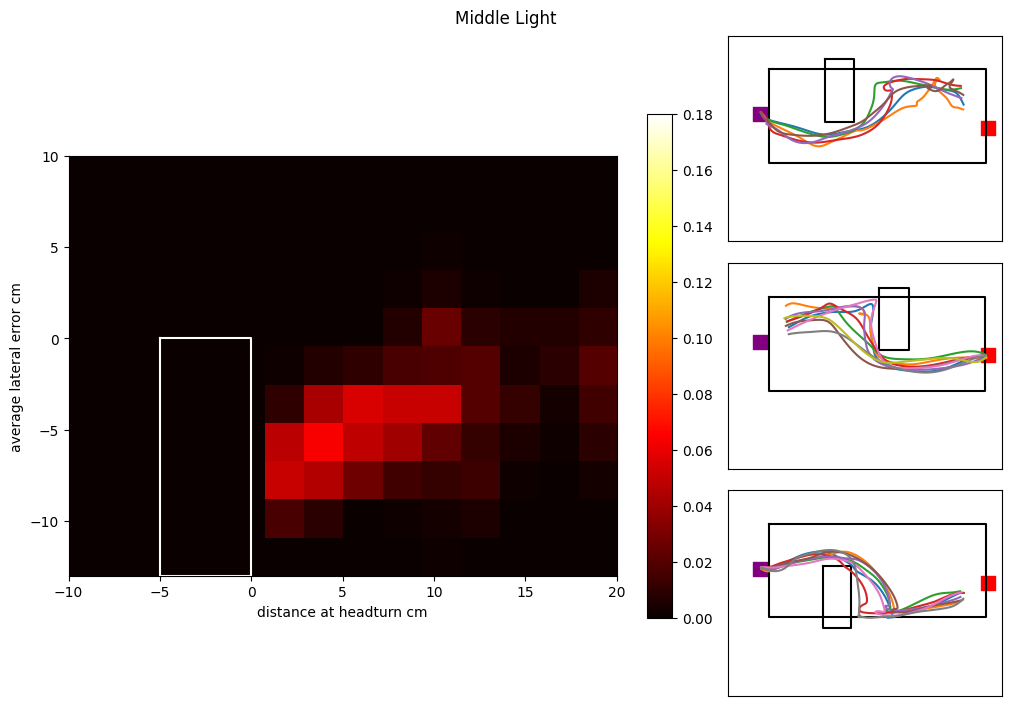

In [269]:


fig = plt.figure(layout = 'constrained',figsize=(10,7))
fig.suptitle('Middle Light')

gs = GridSpec(ncols=6, nrows=6,figure=fig)

ax1 = fig.add_subplot(gs[:, :4])
ax1.set_xlabel('distance at headturn cm')
ax1.set_ylabel('average lateral error cm')

data = pd.concat([long,short])
data = data[(data.date_index == 4)&(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

#ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax1.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
fig.colorbar(ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)


ax2 = fig.add_subplot(gs[0:2, 4:])
ax2.set_xticks([])
ax2.set_yticks([])
trace_ax2 = data[(data.animal == 'J701LT') &(data.obstacle_cluster == 0)&(data.odd == 'right')]
plot_arena(trace_ax2,ax2,0)
plot_orginal_obstacle(trace_ax2,ax2,0)
for ind,row in trace_ax2.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax2.plot(x,y)




ax3 = fig.add_subplot(gs[2:4, 4:])
ax3.set_xticks([])
ax3.set_yticks([])
trace_ax3 = data[(data.animal == 'J701RT') &(data.obstacle_cluster == 1)&(data.odd == 'left')]
plot_arena(trace_ax3,ax3)
plot_orginal_obstacle(trace_ax3,ax3,1)
for ind,row in trace_ax3.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax3.plot(x,y)

             

ax4 = fig.add_subplot(gs[4:6, 4:])
ax4.set_xticks([])
ax4.set_yticks([])
trace_ax4 = data[(data.animal == 'J701NN') &(data.obstacle_cluster == 4)&(data.odd == 'right')]
plot_arena(trace_ax4,ax4)
plot_orginal_obstacle(trace_ax4,ax4,4)
for ind,row in trace_ax4.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax4.plot(x,y)

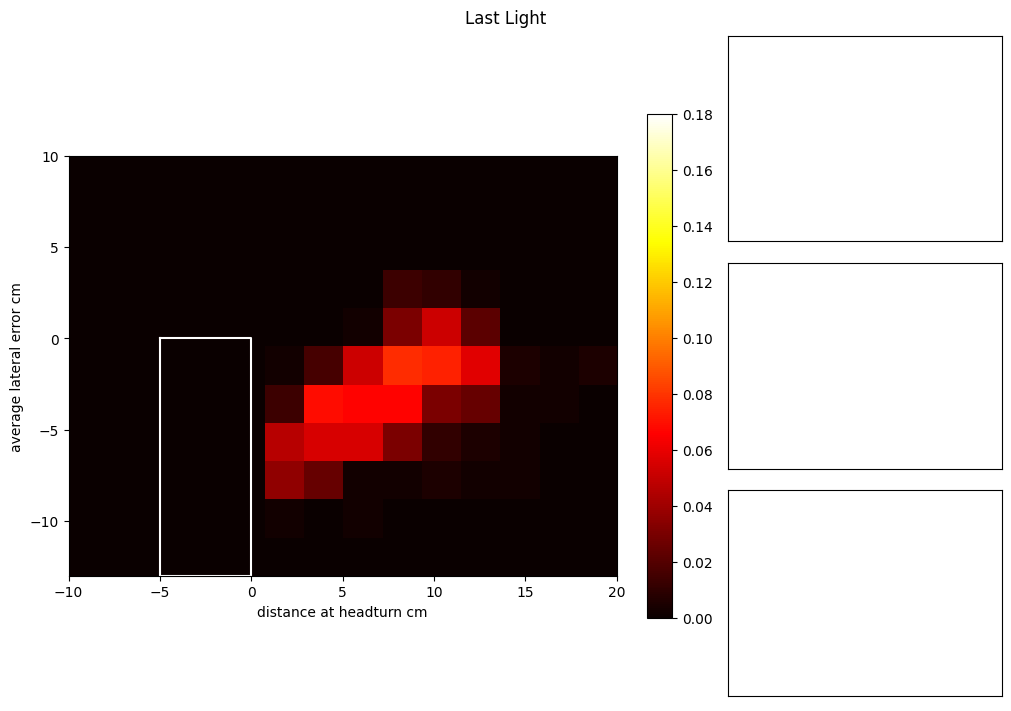

In [277]:


fig = plt.figure(layout = 'constrained',figsize=(10,7))
fig.suptitle('Last Light')

gs = GridSpec(ncols=6, nrows=6,figure=fig)

ax1 = fig.add_subplot(gs[:, :4])
ax1.set_xlabel('distance at headturn cm')
ax1.set_ylabel('average lateral error cm')

data = pd.concat([short])
data = data[(data.date_index == 6)&(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

#ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax1.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
fig.colorbar(ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)


ax2 = fig.add_subplot(gs[0:2, 4:])
ax2.set_xticks([])
ax2.set_yticks([])
trace_ax2 = data[(data.animal == 'J701LT') &(data.obstacle_cluster == 0)&(data.odd == 'right')]
plot_arena(trace_ax2,ax2,0)
plot_orginal_obstacle(trace_ax2,ax2,0)
for ind,row in trace_ax2.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax2.plot(x,y)




ax3 = fig.add_subplot(gs[2:4, 4:])
ax3.set_xticks([])
ax3.set_yticks([])
trace_ax3 = data[(data.animal == 'J701RT') &(data.obstacle_cluster == 1)&(data.odd == 'left')]
plot_arena(trace_ax3,ax3)
plot_orginal_obstacle(trace_ax3,ax3,1)
for ind,row in trace_ax3.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax3.plot(x,y)

             

ax4 = fig.add_subplot(gs[4:6, 4:])
ax4.set_xticks([])
ax4.set_yticks([])
trace_ax4 = data[(data.animal == 'J701NN') &(data.obstacle_cluster == 4)&(data.odd == 'right')]
plot_arena(trace_ax4,ax4)
plot_orginal_obstacle(trace_ax4,ax4,4)
for ind,row in trace_ax4.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax4.plot(x,y)

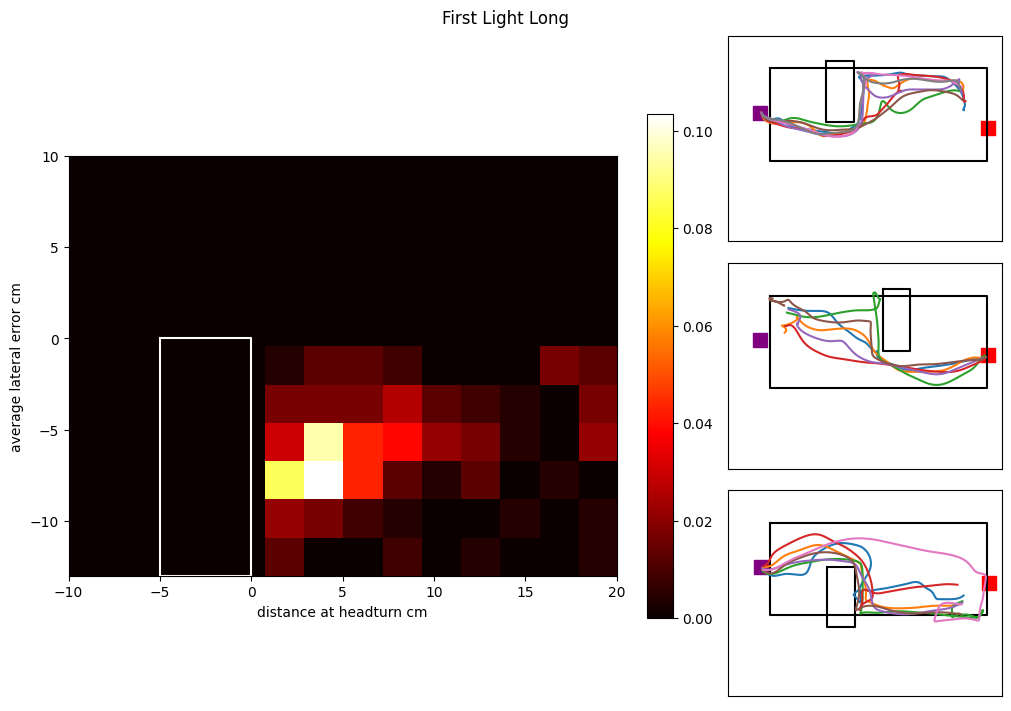

In [293]:


fig = plt.figure(layout = 'constrained',figsize=(10,7))
fig.suptitle('First Light Long')

gs = GridSpec(ncols=6, nrows=6,figure=fig)

ax1 = fig.add_subplot(gs[:, :4])
ax1.set_xlabel('distance at headturn cm')
ax1.set_ylabel('average lateral error cm')

data = pd.concat([long])
data = data[(data.date_index == 0)&(data.distance_at_head_turn >= 0) &(data.avg_lateral_error<= -1)]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

#ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax1.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
fig.colorbar(ax1.imshow(array[::-1]/len(data),cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)


ax2 = fig.add_subplot(gs[0:2, 4:])
ax2.set_xticks([])
ax2.set_yticks([])
trace_ax2 = data[(data.animal == 'J701LT') &(data.obstacle_cluster == 0)&(data.odd == 'right')]
plot_arena(trace_ax2,ax2,0)
plot_orginal_obstacle(trace_ax2,ax2,0)
for ind,row in trace_ax2.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax2.plot(x,y)




ax3 = fig.add_subplot(gs[2:4, 4:])
ax3.set_xticks([])
ax3.set_yticks([])
trace_ax3 = data[(data.animal == 'J701LT') &(data.obstacle_cluster == 1)&(data.odd == 'left')]
plot_arena(trace_ax3,ax3)
plot_orginal_obstacle(trace_ax3,ax3,1)
for ind,row in trace_ax3.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax3.plot(x,y)

             

ax4 = fig.add_subplot(gs[4:6, 4:])
ax4.set_xticks([])
ax4.set_yticks([])
trace_ax4 = data[(data.animal == 'J701NN') &(data.obstacle_cluster == 4)&(data.odd == 'right')]
plot_arena(trace_ax4,ax4)
plot_orginal_obstacle(trace_ax4,ax4,4)
for ind,row in trace_ax4.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax4.plot(x,y)

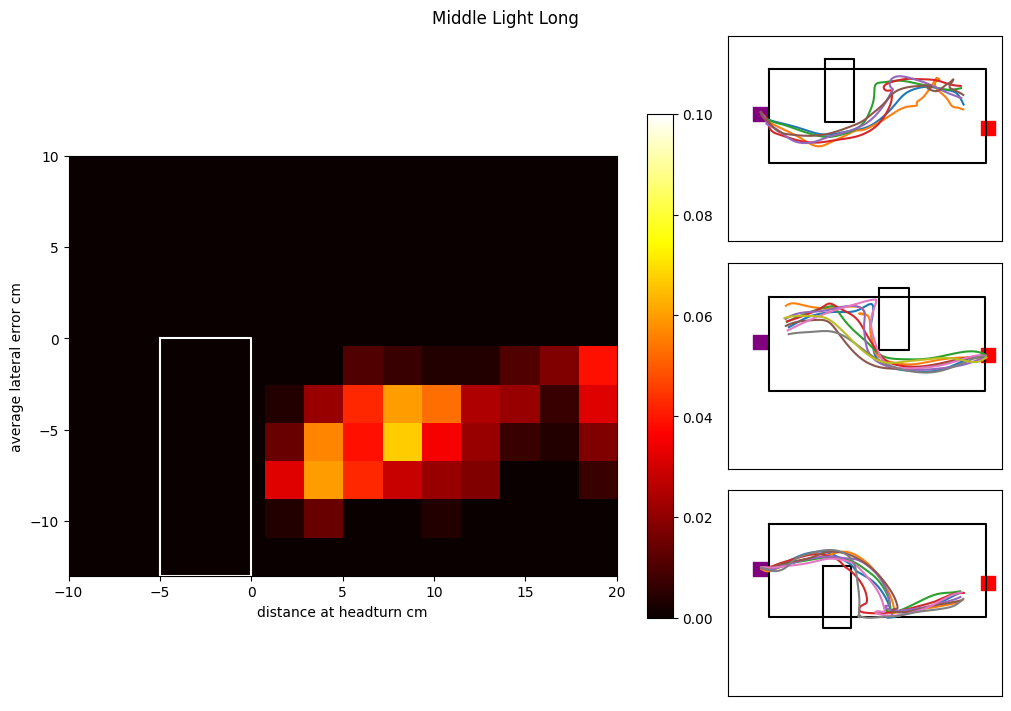

In [297]:


fig = plt.figure(layout = 'constrained',figsize=(10,7))
fig.suptitle('Middle Light Long')

gs = GridSpec(ncols=6, nrows=6,figure=fig)

ax1 = fig.add_subplot(gs[:, :4])
ax1.set_xlabel('distance at headturn cm')
ax1.set_ylabel('average lateral error cm')

data = pd.concat([long])
data = data[(data.date_index == 4)&(data.distance_at_head_turn >= 0) &(data.avg_lateral_error<= -1)]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

#ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax1.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
fig.colorbar(ax1.imshow(array[::-1]/len(data),vmax = .10,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)


ax2 = fig.add_subplot(gs[0:2, 4:])
ax2.set_xticks([])
ax2.set_yticks([])
trace_ax2 = data[(data.animal == 'J701LT') &(data.obstacle_cluster == 0)&(data.odd == 'right')]
plot_arena(trace_ax2,ax2,0)
plot_orginal_obstacle(trace_ax2,ax2,0)
for ind,row in trace_ax2.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax2.plot(x,y)




ax3 = fig.add_subplot(gs[2:4, 4:])
ax3.set_xticks([])
ax3.set_yticks([])
trace_ax3 = data[(data.animal == 'J701RT') &(data.obstacle_cluster == 1)&(data.odd == 'left')]
plot_arena(trace_ax3,ax3)
plot_orginal_obstacle(trace_ax3,ax3,1)
for ind,row in trace_ax3.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax3.plot(x,y)

             

ax4 = fig.add_subplot(gs[4:6, 4:])
ax4.set_xticks([])
ax4.set_yticks([])
trace_ax4 = data[(data.animal == 'J701NN') &(data.obstacle_cluster == 4)&(data.odd == 'right')]
plot_arena(trace_ax4,ax4)
plot_orginal_obstacle(trace_ax4,ax4,4)
for ind,row in trace_ax4.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax4.plot(x,y)

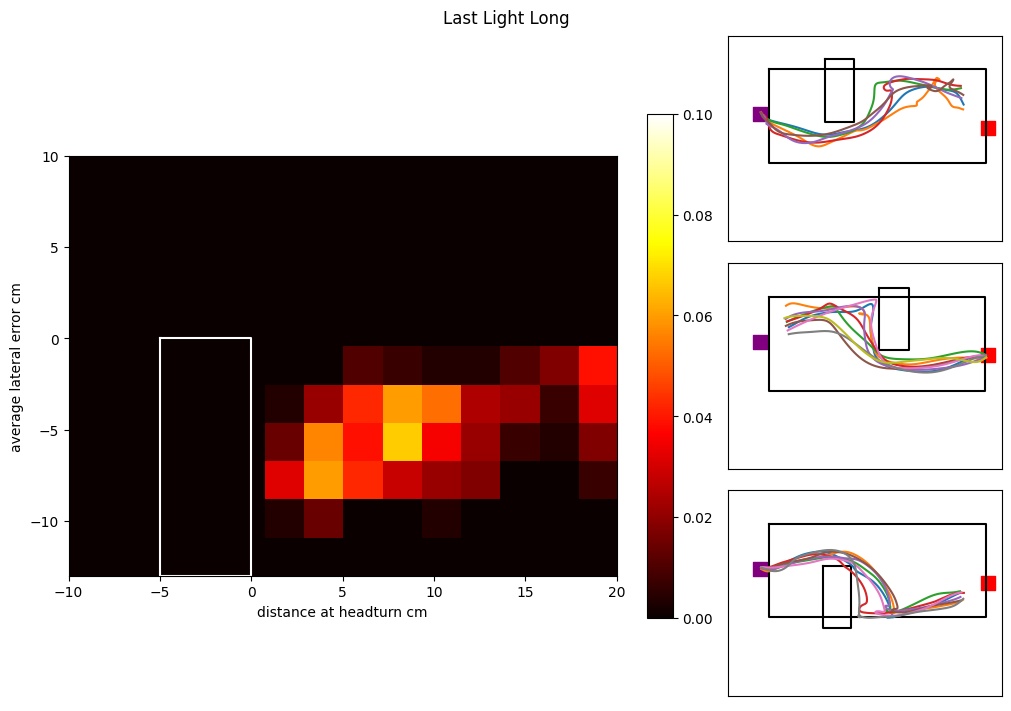

In [295]:


fig = plt.figure(layout = 'constrained',figsize=(10,7))
fig.suptitle('Last Light Long')

gs = GridSpec(ncols=6, nrows=6,figure=fig)

ax1 = fig.add_subplot(gs[:, :4])
ax1.set_xlabel('distance at headturn cm')
ax1.set_ylabel('average lateral error cm')

data = pd.concat([long])
data = data[(data.date_index == 4)&(data.distance_at_head_turn >= 0) &(data.avg_lateral_error<= -1)]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

#ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax1.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
fig.colorbar(ax1.imshow(array[::-1]/len(data),vmax = .10,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)


ax2 = fig.add_subplot(gs[0:2, 4:])
ax2.set_xticks([])
ax2.set_yticks([])
trace_ax2 = data[(data.animal == 'J701LT') &(data.obstacle_cluster == 0)&(data.odd == 'right')]
plot_arena(trace_ax2,ax2,0)
plot_orginal_obstacle(trace_ax2,ax2,0)
for ind,row in trace_ax2.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax2.plot(x,y)




ax3 = fig.add_subplot(gs[2:4, 4:])
ax3.set_xticks([])
ax3.set_yticks([])
trace_ax3 = data[(data.animal == 'J701RT') &(data.obstacle_cluster == 1)&(data.odd == 'left')]
plot_arena(trace_ax3,ax3)
plot_orginal_obstacle(trace_ax3,ax3,1)
for ind,row in trace_ax3.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax3.plot(x,y)

             

ax4 = fig.add_subplot(gs[4:6, 4:])
ax4.set_xticks([])
ax4.set_yticks([])
trace_ax4 = data[(data.animal == 'J701NN') &(data.obstacle_cluster == 4)&(data.odd == 'right')]
plot_arena(trace_ax4,ax4)
plot_orginal_obstacle(trace_ax4,ax4,4)
for ind,row in trace_ax4.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax4.plot(x,y)

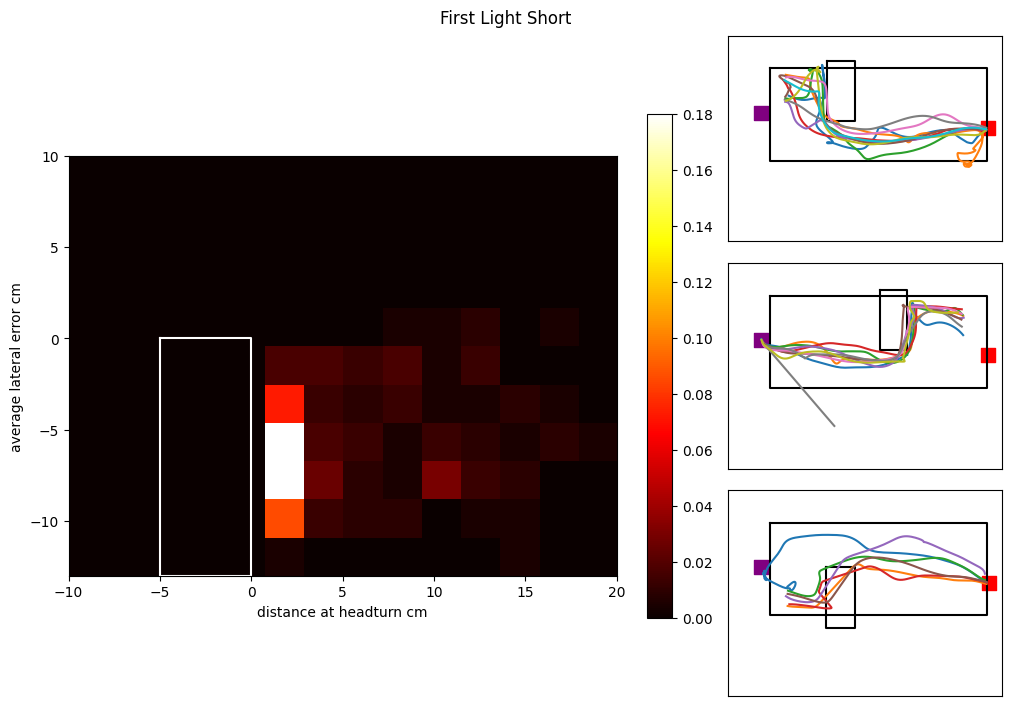

In [288]:


fig = plt.figure(layout = 'constrained',figsize=(10,7))
fig.suptitle('First Light Short')

gs = GridSpec(ncols=6, nrows=6,figure=fig)

ax1 = fig.add_subplot(gs[:, :4])
ax1.set_xlabel('distance at headturn cm')
ax1.set_ylabel('average lateral error cm')

data = pd.concat([short])
data = data[(data.date_index == 0)&(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

#ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax1.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
fig.colorbar(ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)


ax2 = fig.add_subplot(gs[0:2, 4:])
ax2.set_xticks([])
ax2.set_yticks([])
trace_ax2 = data[(data.animal == 'J701LT') &(data.obstacle_cluster == 0)&(data.odd == 'left')]
plot_arena(trace_ax2,ax2,0)
plot_orginal_obstacle(trace_ax2,ax2,0)
for ind,row in trace_ax2.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax2.plot(x,y)




ax3 = fig.add_subplot(gs[2:4, 4:])
ax3.set_xticks([])
ax3.set_yticks([])
trace_ax3 = data[(data.animal == 'J701LT') &(data.obstacle_cluster == 1)&(data.odd == 'right')]
plot_arena(trace_ax3,ax3)
plot_orginal_obstacle(trace_ax3,ax3,1)
for ind,row in trace_ax3.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax3.plot(x,y)

             

ax4 = fig.add_subplot(gs[4:6, 4:])
ax4.set_xticks([])
ax4.set_yticks([])
trace_ax4 = data[(data.animal == 'J701NN') &(data.obstacle_cluster == 4)&(data.odd == 'left')]
plot_arena(trace_ax4,ax4)
plot_orginal_obstacle(trace_ax4,ax4,4)
for ind,row in trace_ax4.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax4.plot(x,y)

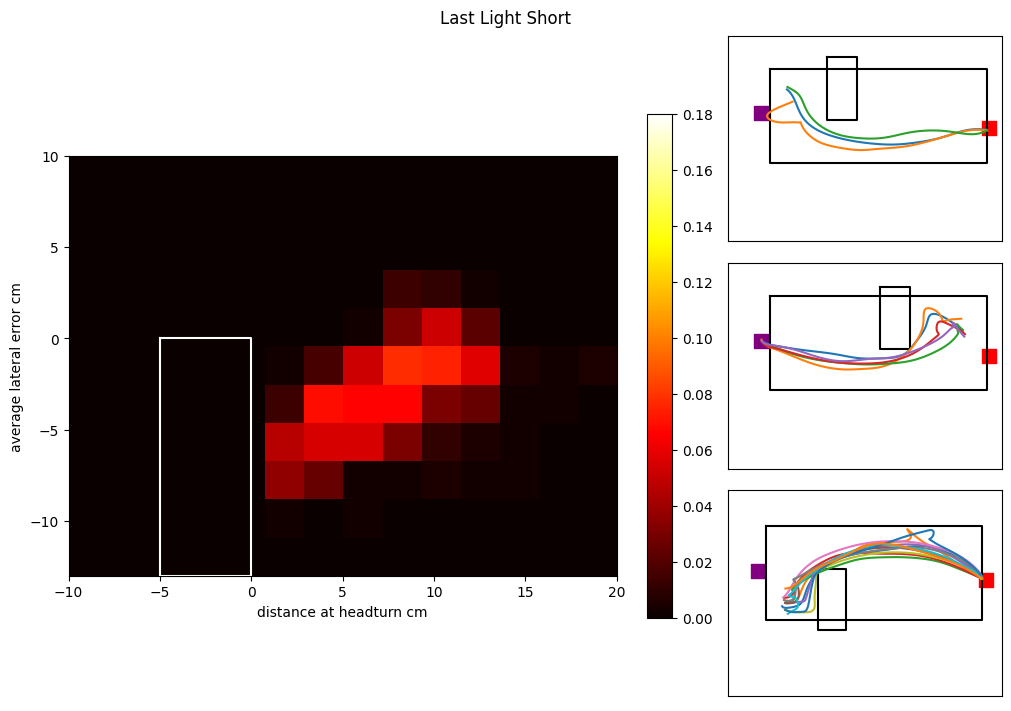

In [286]:


fig = plt.figure(layout = 'constrained',figsize=(10,7))
fig.suptitle('Last Light Short')

gs = GridSpec(ncols=6, nrows=6,figure=fig)

ax1 = fig.add_subplot(gs[:, :4])
ax1.set_xlabel('distance at headturn cm')
ax1.set_ylabel('average lateral error cm')

data = pd.concat([short])
data = data[(data.date_index == 6)&(data.distance_at_head_turn >= 0) ]
ymin,ymax = -10,20
xmin,xmax = -13,10

head_turn,lateral_error = data.distance_at_head_turn.to_numpy(),data.avg_lateral_error.to_numpy()

array ,xedges ,yedges   = np.histogram2d(lateral_error.astype(float), head_turn.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))

#ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax])

ax1.plot( [-5,0,0,-5,-5], [0,0,-13,-13,0],c ='white')
fig.colorbar(ax1.imshow(array[::-1]/len(data),vmax = .18,cmap='hot',extent=[ymin,ymax,xmin,xmax]),fraction=0.046, pad=0.04)


ax2 = fig.add_subplot(gs[0:2, 4:])
ax2.set_xticks([])
ax2.set_yticks([])
trace_ax2 = data[(data.animal == 'J701LT') &(data.obstacle_cluster == 0)&(data.odd == 'left')]
plot_arena(trace_ax2,ax2,0)
plot_orginal_obstacle(trace_ax2,ax2,0)
for ind,row in trace_ax2.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax2.plot(x,y)




ax3 = fig.add_subplot(gs[2:4, 4:])
ax3.set_xticks([])
ax3.set_yticks([])
trace_ax3 = data[(data.animal == 'J701LT') &(data.obstacle_cluster == 1)&(data.odd == 'right')]
plot_arena(trace_ax3,ax3)
plot_orginal_obstacle(trace_ax3,ax3,1)
for ind,row in trace_ax3.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax3.plot(x,y)

             

ax4 = fig.add_subplot(gs[4:6, 4:])
ax4.set_xticks([])
ax4.set_yticks([])
trace_ax4 = data[(data.animal == 'J701NN') &(data.obstacle_cluster == 4)&(data.odd == 'left')]
plot_arena(trace_ax4,ax4)
plot_orginal_obstacle(trace_ax4,ax4,4)
for ind,row in trace_ax4.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax4.plot(x,y)